In [ ]:
# MIT License
#
#@title Copyright (c) 2026 CCAI Community Authors { display-mode: "form" }
#
# Permission is hereby granted, free of charge, to any person obtaining a
# copy of this software and associated documentation files (the "Software"),
# to deal in the Software without restriction, including without limitation
# the rights to use, copy, modify, merge, publish, distribute, sublicense,
# and/or sell copies of the Software, and to permit persons to whom the
# Software is furnished to do so, subject to the following conditions:
#
# The above copyright notice and this permission notice shall be included in
# all copies or substantial portions of the Software.
#
# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
# IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
# FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL
# THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
# LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING
# FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER
# DEALINGS IN THE SOFTWARE.

# NLP Models for Climate Policy Analysis Part 1: Evidence Synthesis

Authors:
*   Daniel Spokoyny, Carnegie Mellon University, dspokoyn@cs.cmu.edu
*   Max Callaghan, Mercator Research Institute on Global Commons and Climate - Berlin, callaghan@mcc-berlin.net
*   Tobias Schimanski, University of Zurich, tobias.schimanski@df.uzh.ch

# Table of Contents

*   [Target Audience](#target-audience)
*   [Overview](#overview)
*   [Contributions](#contributions)
*   [Software Requirements](#software-requirements)
*   [Data Source](#data-source)
*   [Model Pipeline](#model-pipeline)
*   [Model Evaluation](#model-evaluation)

<a name="target-audience"></a>
# Target Audience

*   Climate scientists seeking to explore how to apply NLP technologies to analyze academic papers on climate change.
*   Data scientists with minimal background in machine learning looking for concrete examples of applying NLP for climate policy texts.
* Policy analysts seeking to synthesie evidence or run large-scale analyses.

<a name="overview"></a>
# Overview

This first tutorial explains the application of simple machine learning methods for climate document analysis. You may consider this as **"the world before LLMs"**. These tools are **highly efficient** and can facilitate large-scale analyses that can run on your computer with low hardware requirements, and especially no use of external APIs. Hence, these tools are **locally employable**.

Our use case is literature analysis. It is essential that regulators, law makers, and policitians **write** informed climate policy decisions and **evaluate** existing climate policies based on scientific evidence.
Climate policy evaluation, which can help the development, assessment, and improvement of regulation, increases transparency and public support, and encourages public and private sector entities to make pledges or increase their levels of action.

Academic literature provides a valuable source of information for conducting climate policy evaluation.
Since there is such an *abundance of scientific literature*, it is important to have a systematic review of the literature to write *a report that summarizes* the current state of the science.
However, systematic evidence mapping or identifying which papers are relevant to a particular policy is a necessary first step.

In this tutorial, we will explore how Natural Language Processing (NLP) can be used to assist in identifying and mapping climate-relevant literature using a supervised learning approach.


The outline of the tutorial is as follows:

(1) We will explore the dataset and build a pipeline for a simple machine learning model, \
(2) Then demonstrate how to train a supervised SVM classifier which is a more sophisticated model, \
(3) Finally, we will train and evaluate pretrained transformer models.

<a name="contributions"></a>
# Contributions

Through introductory presentations and colab notebooks, we aim to expose the participants to:

(a) An example of a task pertinent to **climate policy analysis** \
(b) Build an intuition for simple **NLP count based** models and classification metrics\
(c) Learn more advanced **supervised learning** models such as SVMs and transformers

<a name="Motivation"></a>
# Motivation

![Cover of 5th IPCC report](https://github.com/dspoka/ccai-nlp-tutorial-2023/blob/main/images/syrcover.png?raw=1)

It is the job of the [IPCC](https://www.ipcc.ch/) to provide comprehensive, objective and transparent assessments of the scientific literature on climate change. The reports, which are published every 6-7, years serve as trusted sources of information across climate science, impacts & adaptation, and mitigation. Because the summaries for policymakers are approved by national governments, the reports are also vital in international climate negotiations and are key tools for holding governments accountable.

The three working groups of the IPCC
- WGI: The Physical Science Basis
- WGII: Impacts, Adaptation and Vulnerability
- WGIII: Mitigation of Climate Change

have all recently published their sixth assessment report, with a synthesis report published in March 2023.

## Problem: Comprehensive assessments, an increasingly intractable task

![Graph showing growth in studies on climate change](https://github.com/dspoka/ccai-nlp-tutorial-2023/blob/main/images/literature_growth.svg?raw=1)

Whereas early IPCC reports had hundreds or thousands of scientific studies on climate change to contend with, during the most recent assessment report more than 300,000 studies were published on climate change ([Callaghan et al., 2020](https://www.nature.com/articles/s41558-019-0684-5)). Although the reports have got bigger - involving more authors, comprising more pages, and containing more references - this has not kept pace with the growth in the literature. With the IPCC citing an increasingly small proportion of available relevant literature, the question of what they cite and how this is selected becomes ever more important.

## Evidence synthesis methods
Evidence synthesis ([overview](https://www.lshtm.ac.uk/research/centres/centre-evaluation/evidence-synthesis)) describes a suite of formal methods for selecting and assessing evidence on a research question. These are most frequently used in the medical domain, where important decisions with life-or-death outcomes are rarely made based on single studies, or on "normal" literature reviews (where a single expert or experts select and summarise a literature with no formal procedures for how evidence is selected or assessed).

Evidence synthesis methods prioritise comprehensiveness in the evidence base assessed, as well as transparency in how this is identified, selected and assessed.

## Machine-learning assisted evidence synthesis

Many processes in evidence synthesis, such as screening potentially relevant studies, or coding studies according to the type of evidence they provide, are repetitive and time consuming. As the number of papers grows, these processes present larger and larger challenges to the goal of producing comprehensive assessments.

Repetitive and time consuming tasks are exactly those where machine-learning can be helpful. Research is mostly recorded in written texts, so that means the ML tools we are looking for come from the area of Natural Language Processing (NLP).

So far the uses of ML in evidence synthesis are:

- **Identifying relevant studies**: A simple binary classifier can be trained on human screened data (studies labelled with 0, or 1 for relevant) to predict whether documents without labels will be relevant or not
- **Classifying studies**: Machine learning can be used to give useful content labels to studies, either using
  - **Unsupervised** methods like topic modelling, which need no human input but cannot assign to documents to predefined categories; or
  - **Supervised** methods, where models predict the labels of unseen documents, based on the *predefined* labels assigned by humans.


In this tutorial we will be exploring how we can use supervised methods to identify and classify evidence on climate impacts, following a simplified version of a pipeline used in this [publication](https://www.nature.com/articles/s41558-021-01168-6.epdf?sharing_token=7Sw0J3PwoQNKriW6TbOuX9RgN0jAjWel9jnR3ZoTv0PwAcRfhcoupIk0A95eY8_-YUKjuCHE46BRE8RXMy_HNaRNTl48Ji0i6-pYLEd3WbQwXQpTp1LscjrMM5Am67huate7yo35BOmH8Yq08b_CuYEhHpq1-SwJh0A5XD6kKvE%3D).

<a name="software-requirements"></a>
# Software Requirements
This notebook requires the following libraries:
*   datasets (pip)
*   transformers (pip)

`datasets` is a library which we will use to download the data required.
`transformers` is a library which we will use to load pre-trained language models from.

The package is written using `PyTorch` and `sklearn` machine learning libraries.

In [1]:
# We need to install the following packages to run the code in this notebook
# This should take about 1 to 2 minutes.
# %%capture
!pip install datasets
!pip install transformers
!pip install accelerate

<a name="data-source"></a>
# Data Source

In order to carry out evidence synthesis, we need to get our hands on data from bibliographic databases. There a multitude of different databases out there: some are general, while others are specific to a particular discipline. Some focus solely on peer-reviewed journals, while others may focus on, or also contain, preprints, conference proceedings, scientific reports, PhD theses, or other "grey" literature sources (for an overview of available databases and their disciplinary coverage check out [Gusenbauer, 2022](https://link.springer.com/article/10.1007/s11192-022-04289-7). In evidence synthesis projects, comprehensiveness is important, so searching as many relevant databases *as is practicable* is usually seen as best practice.  

<!-- ![image](images/OpenAlex-logo-5.2de7053c.png) -->

In this tutorial, we have prepared a dataset for you based on a database called [OpenAlex](https://openalex.org/). This database attempts to be as comprehensive as possible. It has some limitations in how you can search, but it does have an open (and importantly unlimited) API, and is free and open source. In this tutorial, we are limited to OpenAlex. This means, we cannot fully reproduce the results of the academic study. If you apply this method to future evidence synthesis, it is advisable to consider broader open-source and proprietary resources.

<br/>

## Data Exploration
We have preprocessed and prepared two sources of data for you to use in this tutorial:
-  labeled_data: which contains "INCLUDE" where 1 means the study was used in the synthesis report, and 0 means it was not.
-  unlabeled_data: which contains studies from the OpenAlex database.
All studies in the labeled_data are "seen", since a human has reviewed them all to conclude whether to include them in the report or not. The unlabeled_data is unseen (seen=0), since they were not reviewed by a human.

Lets download the data and have a look at it.

In [2]:
import pandas as pd
from huggingface_hub import hf_hub_download
import matplotlib.pyplot as plt
import numpy as np
import re

# Here we will download the openalex dataset from the huggingface hub.
filepath = hf_hub_download(repo_id="dspoka/ccai-nlp-tutorial-1", filename="openalex_data.csv", repo_type="dataset")
with open(filepath) as f:
    unlabeled_data = pd.read_csv(f)


print(f'The dataset has {unlabeled_data.shape[0]} rows and {unlabeled_data.shape[1]} columns')
print(f'The columns are: {unlabeled_data.columns.values}')
unlabeled_data.head()

openalex_data.csv:   0%|          | 0.00/28.1M [00:00<?, ?B/s]

The dataset has 24906 rows and 6 columns
The columns are: ['id' 'doi' 'title' 'publication_year' 'abstract' 'authors']


,id,doi,title,publication_year,abstract,authors
0,https://openalex.org/W2076977109,https://doi.org/10.1038/nature03906,Increasing destructiveness of tropical cyclone...,2005,NaN,Kerry Emanuel
1,https://openalex.org/W2171979944,https://doi.org/10.1007/s00425-003-1105-5,"Plant responses to drought, salinity and extre...",2003,NaN,"Wang-Xia Wang, Basia Vinocur, Arie Altman"
2,https://openalex.org/W2122582889,https://doi.org/10.1073/pnas.0505734102,Regional vegetation die-off in response to glo...,2005,Future drought is projected to occur under war...,"David D. Breshears, Neil S. Cobb, Paul Rich, K..."
3,https://openalex.org/W2170327428,https://doi.org/10.1073/pnas.1422385112,Anthropogenic warming has increased drought ri...,2015,Significance California ranks first in the Uni...,"Noah S. Diffenbaugh, Daniel L. Swain, Danielle..."
4,https://openalex.org/W2154180993,https://doi.org/10.1038/nature04188,Impact of regional climate change on human health,2005,NaN,"Jonathan A. Patz, Diarmid Campbell-Lendrum, Tr..."


## Understanding the OpenAlex Dataset (unlabeled_data)
- Each row corresponds to an academic paper and has some columns with metadata like the publication year, list of authors, etc.
- The important columns that we will use are
    - 'abstract' and the 'title' which is string text.
    - A unique identifier called 'id'.
    - And some metadata like 'publication_year', 'authors', 'doi'.

## Basic exploration
Now that we have the data in a convenient format, we can begin to explore the data, e.g. by plotting the number of publications in each year

(24906, 6)


<Axes: xlabel='publication_year'>

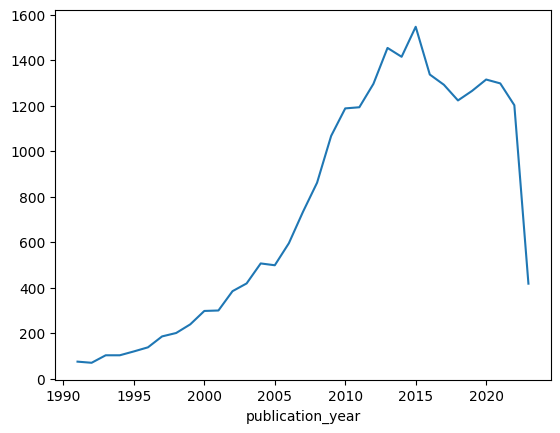

In [3]:
print(unlabeled_data.shape)
unlabeled_data.query("publication_year>1990").groupby("publication_year")["id"].count().plot()

<a name="model-pipeline"></a>
# Model Pipeline

In this part we'll go through the steps we need to take to load labelled data and train a model to predict a label based on text input. We'll start off with a simple model using Support Vector Machines (SVMs), before exploring how we would do this using by fine-tuning a language model using [transformers](https://huggingface.co/docs/transformers/index) 🤗

## Labeled Data

We'll start by loading our labels and merging these with the studies we downloaded from OpenAlex

In [4]:
filepath = hf_hub_download(repo_id="dspoka/ccai-nlp-tutorial-1", filename="labelled_data.csv", repo_type="dataset")
with open(filepath) as f:
    labeled_data = pd.read_csv(f)

# We create a lower case version of the title without spaces and punctuation, to allow for merging
labeled_data["title_lcase"] = labeled_data["title"].apply(lambda x: re.sub("\W", "", x).lower() if isinstance(x, str) else x)

# We also want to get rid of documents without abstracts, as we can't use these for learning
labeled_data = labeled_data.dropna(subset=["abstract"])
print(labeled_data.shape)
labeled_data.head()

<>:6: SyntaxWarning: invalid escape sequence '\W'
<>:6: SyntaxWarning: invalid escape sequence '\W'
/tmp/ipykernel_2361/341116838.py:6: SyntaxWarning: invalid escape sequence '\W'
  labeled_data["title_lcase"] = labeled_data["title"].apply(lambda x: re.sub("\W", "", x).lower() if isinstance(x, str) else x)


labelled_data.csv:   0%|          | 0.00/4.45M [00:00<?, ?B/s]

(2500, 11)


,id,abstract,title,seen,INCLUDE,12 - Coastal and marine Ecosystems,12 - Human and managed,"12 - Mountains, snow and ice","12 - Rivers, lakes, and soil moisture",12 - Terrestrial ES,title_lcase
0,1448689,"The city of Bismarck, North Dakota has one of ...",Key Factors Influencing the Incidence of West ...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,keyfactorsinfluencingtheincidenceofwestnilevir...
1,3281128,Changing precipitation regimes can profoundly ...,Asymmetric responses of plant community struct...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,asymmetricresponsesofplantcommunitystructurean...
2,900708,Climate influences forest structure through ef...,Climate effects on fire regimes and tree recru...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,climateeffectsonfireregimesandtreerecruitmenti...
3,3234419,"Climate change is likely to bring more, hotter...",Climate change adaptation and mitigation ? a h...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,climatechangeadaptationandmitigationahitherton...
4,2090028,Aim The long-term stability of coastal ecosyst...,Caribbean mangroves adjust to rising sea level...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,caribbeanmangrovesadjusttorisingsealevelthroug...


In [5]:
# Now we load the Open alex data, and create the same title variable for merging
unlabeled_data = unlabeled_data.rename(columns={"id": "OA_id"})
unlabeled_data["title_lcase"] = unlabeled_data["title"].apply(lambda x: re.sub("\W", "", x).lower() if isinstance(x, str) else x)
unlabeled_data = unlabeled_data.dropna(subset=["abstract"]).copy()
unlabeled_data.loc[:, "seen"] = 0
print(f'The dataset has {unlabeled_data.shape[0]} rows and {unlabeled_data.shape[1]} columns')
#unlabeled_data.head()

# Now we add the OpenAlex rows which are not in the labelled data to the labelled_data
# print(unlabeled_data[~unlabeled_data["title_lcase"].isin(labeled_data["title_lcase"])].shape)

df = pd.concat(
    [labeled_data, unlabeled_data[~unlabeled_data["title_lcase"].isin(labeled_data["title_lcase"])]]
)
print(df.shape)
df.head()

<>:3: SyntaxWarning: invalid escape sequence '\W'
<>:3: SyntaxWarning: invalid escape sequence '\W'
/tmp/ipykernel_2361/1841148473.py:3: SyntaxWarning: invalid escape sequence '\W'
  unlabeled_data["title_lcase"] = unlabeled_data["title"].apply(lambda x: re.sub("\W", "", x).lower() if isinstance(x, str) else x)


The dataset has 18556 rows and 8 columns
(20771, 15)


,id,abstract,title,seen,INCLUDE,12 - Coastal and marine Ecosystems,12 - Human and managed,"12 - Mountains, snow and ice","12 - Rivers, lakes, and soil moisture",12 - Terrestrial ES,title_lcase,OA_id,doi,publication_year,authors
0,1448689.0,"The city of Bismarck, North Dakota has one of ...",Key Factors Influencing the Incidence of West ...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,keyfactorsinfluencingtheincidenceofwestnilevir...,NaN,NaN,NaN,NaN
1,3281128.0,Changing precipitation regimes can profoundly ...,Asymmetric responses of plant community struct...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,asymmetricresponsesofplantcommunitystructurean...,NaN,NaN,NaN,NaN
2,900708.0,Climate influences forest structure through ef...,Climate effects on fire regimes and tree recru...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,climateeffectsonfireregimesandtreerecruitmenti...,NaN,NaN,NaN,NaN
3,3234419.0,"Climate change is likely to bring more, hotter...",Climate change adaptation and mitigation ? a h...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,climatechangeadaptationandmitigationahitherton...,NaN,NaN,NaN,NaN
4,2090028.0,Aim The long-term stability of coastal ecosyst...,Caribbean mangroves adjust to rising sea level...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,caribbeanmangrovesadjusttorisingsealevelthroug...,NaN,NaN,NaN,NaN


Importantly, we save the **df** dataset here. We will use it later for our classifiers.

### Inspecting our labels

We can take a quick look at how many of which type of labels we have

Number of seen vs. unseen documents
seen
0.0    18262
1.0     2500
Name: title, dtype: int64
--------------------------------------------------------------------------------
Number of included vs. excluded documents
INCLUDE
0.0    1194
1.0    1306
Name: title, dtype: int64


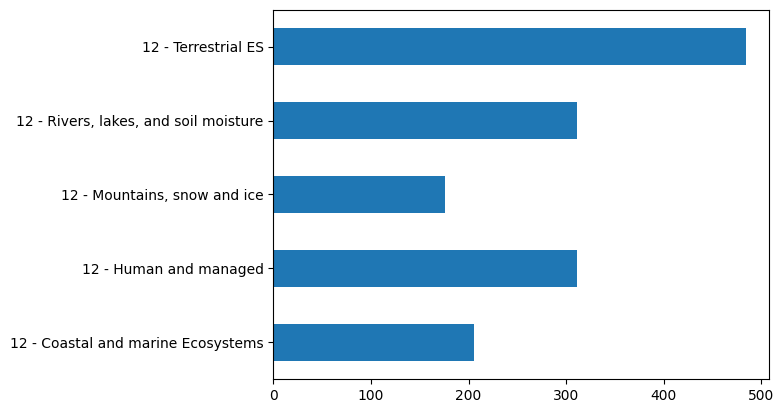

In [6]:
def inspect_labels(df):
    # We can quickly plot how many documents have been labelled, and how many not
    # df.groupby("seen")["title"].count().plot.bar();
    print('Number of seen vs. unseen documents')
    print(df.groupby("seen")["title"].count())
    print('-'*80)
    # and also plot how many of the labelled docs were included
    # df.groupby("INCLUDE")["title"].count().plot.bar()

    print('Number of included vs. excluded documents')
    print(df.groupby("INCLUDE")["title"].count())
    # Finally we can plot how many examples of each impact type we have
    df[impacts].sum().plot.barh();

impacts = [x for x in df.columns if re.match("12 -", x)]
inspect_labels(df)

For training classifiers, it is essential to create a training and testing dataset. Hence, we define the following function:

In [7]:
from sklearn.model_selection import train_test_split
def train_test_split_df(df):
    ''' Gets train/test splits for INCLUDE prediction task.
    '''
    # select only the seen documents
    all_seen = df[df["seen"] == 1].sample(2000).index
    all_x = df[df["seen"] == 1]["abstract"].values
    all_y = df[df["seen"] == 1]["INCLUDE"].values.astype(int)
    # percent of data to use for train, val, test
    train_size = 0.8
    # train_size = 0.01
    # get the indices for each split
    x_train, x_test, y_train, y_test = train_test_split(all_x, all_y, train_size=train_size, random_state=42)
    assert len(x_train) == len(y_train)
    assert len(x_test) == len(y_test)
    print (f"Train size: {len(x_train)}")
    print (f"Test size: {len(x_test)}")
    return x_train, y_train, x_test, y_test

## A pipeline for a simple machine learning model

Now we want to put together a pipeline for a simple machine learning model. We'll start off by trying to predict the binary INCLUSION label, then move onto the impact type, which is a **multilabel** output. This means each document can be labelled with one or more of the impact types.

In each case, though, the first thing we need to do is to encode our text input, so it can be used in our models. To do this, we'll take a look at approaches from the feature extraction module from [scikitlearn](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.feature_extraction.text): `CountVectorizer` and `TfidfVectorizer`.

In [8]:
def visualize_doc_vec(X, features=None):
    '''Simple function to visualise a document-term matrix'''
    print('Document-term matrix:\n', X.todense())
    # And we could visualise this simply like this
    fig, ax = plt.subplots()
    doc_map = ax.imshow(X.todense(), cmap="Blues")
    ax.set_xticks(np.arange(len(features)))
    ax.set_xticklabels(features, rotation=45, ha="right")
    cbar = fig.colorbar(doc_map)
    plt.show()

from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer


def show_raw_counts(texts):
    '''
    Function to show the raw counts of words in a corpus and visualize them.
    '''
    # We'll instantiate a vectorizer class
    vectorizer = CountVectorizer()

    # And apply the fit_transform method to our texts
    X = vectorizer.fit_transform(texts)

    # This gives us a matrix of shape n_texts, vocab_size
    X.todense()

    # The features each column represents can be accessed here
    features = vectorizer.get_feature_names_out()
    visualize_doc_vec(X, features)

Document-term matrix:
 [[0 0 1 1 0 0 1 1 1 0 0 1]
 [1 1 1 1 1 1 0 0 1 0 0 0]
 [0 0 2 1 0 0 0 0 0 1 1 0]]


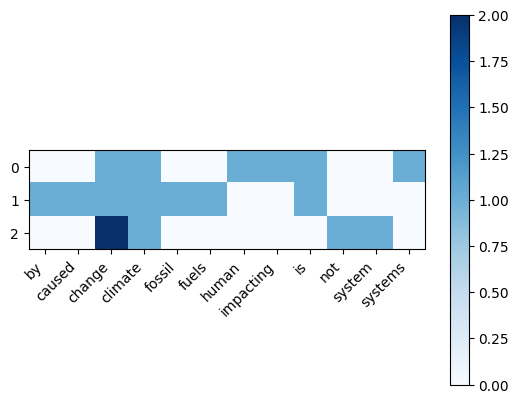

In [9]:
# Let's take for now a couple of example texts
texts = [
    "Climate change is impacting human systems",
    "Climate change is caused by fossil fuels",
    "System change not climate change",
]
# And now lets visualize the raw word counts in our 3 sentences.
show_raw_counts(texts)

As we can see, each document is a row, each column is a feature. The cells contain the number of times each word occurs in each document.

However, by adding a small amount of complexity we can generate a more useful way of representing these texts.

Term frequency inverse document frequency ([TF-IDF](https://en.wikipedia.org/wiki/Tf%E2%80%93idf)) gives greater weight to those terms which appear infrequently in the corpus, meaning that very frequent but uninformative terms like "the" are given less importance.

In [10]:
def show_tfidf(texts):
    '''
    Function to show the tf-idf scores of words in a corpus and visualize them.
    '''
    # We'll instantiate a term frequency - inverse document frequency vectorizer class
    vectorizer = TfidfVectorizer()

    # And apply the fit_transform method to our texts
    X = vectorizer.fit_transform(texts)

    # This gives us a matrix of shape n_texts, vocab_size
    X.todense()

    # The features each column represents can be accessed here
    features = vectorizer.get_feature_names_out()
    visualize_doc_vec(X, features)

Document-term matrix:
 [[0.         0.         0.28561676 0.28561676 0.         0.
  0.48359121 0.48359121 0.36778358 0.         0.         0.48359121]
 [0.43535684 0.43535684 0.25712876 0.25712876 0.43535684 0.43535684
  0.         0.         0.3311001  0.         0.         0.        ]
 [0.         0.         0.61046311 0.30523155 0.         0.
  0.         0.         0.         0.51680194 0.51680194 0.        ]]


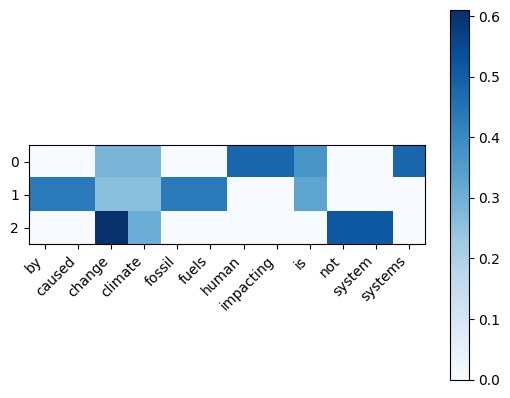

In [11]:
show_tfidf(texts)

## Learning from features

Support Vector Machines (SVM) work by finding a hyperplane in a multi-dimensional space that separates samples of different classes. The matrix we have visualised above forms our multidimensional space. In simple words, an SVM builds a decision boundary between classes. For this, the classes need labels (which the dataset above fortunately has and we will simulate for now).

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

def build_svm(toy_texts, y):
    '''
    Function to create a pipeline with a tf-idf vectorizer and a support vector machine classifier.
    '''
    svm_classifier = Pipeline(
        steps=[
            ("vect", TfidfVectorizer()),
            ("clf", SVC(probability=True, class_weight="balanced")),
        ]
    )
    svm_classifier.fit(toy_texts, y)
    return svm_classifier


# We'll slightly expand our list of texts
toy_texts, y = zip(
    *[
        ("Climate change is impacting human systems", 1),
        ("Climate change is caused by fossil fuels", 0),
        ("Agricultural yields are affected by climate change", 1),
        ("System change not climate change", 0),
        ("higher temperatures are impacting human health", 1),
        ("Forest fires are becoming more frequent due to climate change", 1),
        ("Machine learning can read texts", 0),
        ("AI can help solve climate change!", 0),
        ("We need to save gas this winter", 0),
        ("More frequent droughts are impacting crop yields", 1),
        ("Many communities are affected by rising sea levels", 1),
        ("Global emissions continue to rise", 0),
        ("Ecosystems are increasingly impacted by rising temperatures", 1),
        ("Emissions from fossil fuels need to decline", 0),
        ("Anthropogenic climate change is impacting vulnerable communities", 1),
    ]
)

# Now lets build a simple SVM classifier on this toy data

svm_classifier = build_svm(toy_texts, y)
svm_classifier

Pipeline(steps=[('vect', TfidfVectorizer()),
                ('clf', SVC(class_weight='balanced', probability=True))])

In [13]:
# We can now use this classifier to make predictions about new texts

# Here are a couple of easy examples (easy because they are similar to our examples)
new_texts = [
    "climate change is impacting terrestrial ecosystems",
    "Machine Learning will solve climate change",
    "Coca Cola is a company that produces sugary drinks",
]
# We can make predictions about which class the examples belong to
print('predictions:', svm_classifier.predict(new_texts))
# We can also get these as probabilities (which are very unstable with small datasets, and not guaranteed to match the predictions)
print('probabilities:\n', svm_classifier.predict_proba(new_texts))

predictions: [1 0 1]
probabilities:
 [[0.29780494 0.70219506]
 [0.6956054  0.3043946 ]
 [0.42588792 0.57411208]]


In [14]:
# Each row contains predicted probabilites for each class, in this case 0, and 1

# We can get predicted probabilities of being in the INCLUDE class like this
# One for each of the three examples
svm_classifier.predict_proba(new_texts)[:, 1]

array([0.70219506, 0.3043946 , 0.57411208])

In [15]:
from sklearn.metrics import classification_report

def train_eval_svm(df):
    '''
    Function to that trains with train data and evalutes the model with test data.
    '''
    # load the train/test splits
    x_train, y_train, x_test, y_test = train_test_split_df(df)
    # build the classifier
    svm_classifier = build_svm(x_train, y_train)
    # get the predictions on the test set
    test_pred = svm_classifier.predict(x_test)
    # Get the classification evaluation metrics
    # This will be covered in more detail later.
    print(classification_report(y_test, test_pred))

In [16]:
# So far this was an illustrative example using toy data. Let's now apply this to our real data.
# takes around 20 seconds to run
train_eval_svm(df)

Train size: 2000
Test size: 500
              precision    recall  f1-score   support

           0       0.84      0.78      0.81       235
           1       0.82      0.87      0.84       265

    accuracy                           0.83       500
   macro avg       0.83      0.83      0.83       500
weighted avg       0.83      0.83      0.83       500



## Multilabel

Multilabel problems are those where any sample can belong to any of the classes (as opposed to multiclass problems where each sample must belong to **exactly 1** class. In our dataset, most documents which were marked as relevant are assigned to one class, with some assigned to two, and very few assigned to three.

In [17]:
# Show the different classes of impacts.
print(impacts)
df[df["INCLUDE"] == 1].head()

['12 - Coastal and marine Ecosystems', '12 - Human and managed', '12 - Mountains, snow and ice', '12 - Rivers, lakes, and soil moisture', '12 - Terrestrial ES']


,id,abstract,title,seen,INCLUDE,12 - Coastal and marine Ecosystems,12 - Human and managed,"12 - Mountains, snow and ice","12 - Rivers, lakes, and soil moisture",12 - Terrestrial ES,title_lcase,OA_id,doi,publication_year,authors
1,3281128.0,Changing precipitation regimes can profoundly ...,Asymmetric responses of plant community struct...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,asymmetricresponsesofplantcommunitystructurean...,NaN,NaN,NaN,NaN
2,900708.0,Climate influences forest structure through ef...,Climate effects on fire regimes and tree recru...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,climateeffectsonfireregimesandtreerecruitmenti...,NaN,NaN,NaN,NaN
3,3234419.0,"Climate change is likely to bring more, hotter...",Climate change adaptation and mitigation ? a h...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,climatechangeadaptationandmitigationahitherton...,NaN,NaN,NaN,NaN
4,2090028.0,Aim The long-term stability of coastal ecosyst...,Caribbean mangroves adjust to rising sea level...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,caribbeanmangrovesadjusttorisingsealevelthroug...,NaN,NaN,NaN,NaN
5,574391.0,Climate change and habitat destruction have be...,Compounded effects of climate change and habit...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,compoundedeffectsofclimatechangeandhabitatalte...,NaN,NaN,NaN,NaN


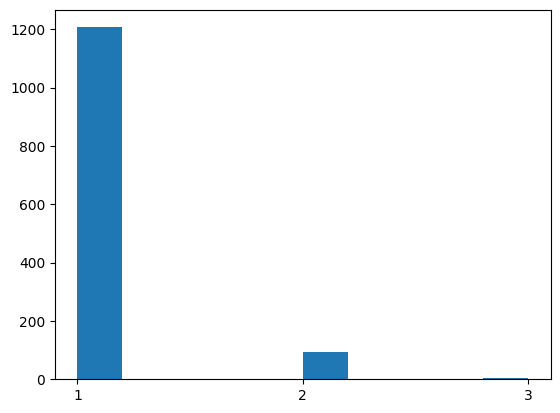

In [18]:
# This plot shows that certain documents have multiple labels for different impacts.
plt.hist(df[df["INCLUDE"] == 1][impacts].sum(axis=1))
plt.xticks(np.arange(1, 4, 1))
plt.show()

To prepare our target for the model, we simply create a matrix with a row for each document and a column for each class

In [19]:
# create an x and y variable with a sample of 200 relevant documents
samples = df[df["INCLUDE"] == 1].sample(200).index
X = df.iloc[samples]["abstract"]
y = df.iloc[samples][impacts].values
np.set_printoptions(threshold=5)
y

array([[0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0.]])

Now we just need to slightly amend our pipeline by defining how we want to approach the multilabel problem.

We use a One vs Rest classifier which simply creates a binary classifier for each class

In [20]:
from sklearn.multiclass import OneVsRestClassifier

clf = Pipeline(
    steps=[
        ("vec", TfidfVectorizer()),
        ("clf", OneVsRestClassifier(SVC(probability=True, class_weight="balanced"))),
    ]
)

clf.fit(X, y)

Pipeline(steps=[('vec', TfidfVectorizer()),
                ('clf',
                 OneVsRestClassifier(estimator=SVC(class_weight='balanced',
                                                   probability=True)))])

In the same way as before, we can make predictions with some sample texts.

In [21]:
example_texts = [
    "Climate change has affected butterfly phenology in North America. "
    + "In an experiment in the butterfly national park, we found that "
    + "mean dates of appearance had shifted by two weeks. Species traits, "
    + "especially ecological traits, were found to explain some part of "
    + "different phenological responses",

    "Rising temperatures have contributed to increasing heat related mortaility "
    + "in cities across Europe. ",
]
y_pred = clf.predict(example_texts)

pd.DataFrame(y_pred, columns=impacts)

,12 - Coastal and marine Ecosystems,12 - Human and managed,"12 - Mountains, snow and ice","12 - Rivers, lakes, and soil moisture",12 - Terrestrial ES
0,0,0,0,0,1
1,0,0,0,0,0


## Transfer learning with transformers!

A more powerful way to do classification is to fine-tune a langauge model which has been pretrained on large amounts of text. For an introduction to how these work (which is outside the scope of this tutorial) check out [The Illustrated Transformer](https://jalammar.github.io/illustrated-transformer/).

The [Transformers](https://huggingface.co/docs/transformers) library makes doing this really easy, and there are a wealth of models available with different features and which have been pretrained on different corpora. We are going to use [ClimateBert](https://huggingface.co/climatebert), which has undergone additional pretraining on texts from the climate domain (included scientific articles).

Thus, a decisive difference to before is that ClimateBERT already learned understanding "language", i.e., the features we extracted from the text before. ClimateBERT fine-tuning will only enable the language-understanding model to learn by example.

In [22]:
# Let's take our texts and our labels again
# Each example is a tuple of (text, label)
# Where a label is 1 if the text is relevant and should be included in a synthesis report and 0 otherwise
texts, y = zip(
    *[
        ("Climate change is impacting human systems", 1),
        ("Climate change is caused by fossil fuels", 0),
        ("Agricultural yields are affected by climate change", 1),
        ("System change not climate change", 0),
        ("higher temperatures are impacting human health", 1),
        ("Forest fires are becoming more frequent due to climate change", 1),
        ("Machine learning can read texts", 0),
        ("AI can help solve climate change!", 0),
        ("We need to save gas this winter", 0),
        ("More frequent droughts are impacting crop yields", 1),
        ("Many communities are affected by rising sea levels", 1),
        ("Global emissions continue to rise", 0),
        ("Ecosystems are increasingly impacted by rising temperatures", 1),
        ("Emissions from fossil fuels need to decline", 0),
        ("Anthropogenic climate change is impacting vulnerable communities", 1),
    ]
)

In [23]:
# To use these with transformers, we are going to need to get them into the right format.
from datasets import Dataset
from transformers import AutoTokenizer

# First we'll put them into a HuggingFace Dataset object
dataset = Dataset.from_dict({"text": texts, "label": y})

# And now we need to tokenize the texts, using the pretrained tokenizer from climatebert
model_name = "climatebert/distilroberta-base-climate-f"
tokenizer = AutoTokenizer.from_pretrained(model_name)


def tokenize_function(examples):
    return tokenizer(examples["text"], padding="longest", truncation=True)


tokenized_dataset = dataset.map(tokenize_function, batched=True)
# input_ids are the token ids for each token in the text
# attention_mask is a mask that tells the model which tokens to pay attention to and which to ignore
# Note the attention mask has 0s for padded tokens.
tokenized_dataset[0]

config.json:   0%|          | 0.00/752 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.46k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.15M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/4.98k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

Map:   0%|          | 0/15 [00:00<?, ? examples/s]

{'text': 'Climate change is impacting human systems',
 'label': 1,
 'input_ids': [0,
  40466,
  464,
  16,
  18081,
  1050,
  1437,
  50278,
  2,
  1,
  1,
  1,
  1,
  1,
  1],
 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0]}

In [24]:
# We can wrap this into one function that turns any set of texts (and optional labels)
# into a tokenized huggingface dataset
def datasetify(x, tokenizer, y=None):
    data_dict = {"text": x}
    if y is not None:
        data_dict["label"] = y
    dataset = Dataset.from_dict(data_dict)

    def tokenize_function(examples):
        return tokenizer(examples["text"], padding="longest", truncation=True)

    return dataset.map(tokenize_function, batched=True)


tokenized_dataset = datasetify(texts, tokenizer, y)
tokenized_dataset[0]

Map:   0%|          | 0/15 [00:00<?, ? examples/s]

{'text': 'Climate change is impacting human systems',
 'label': 1,
 'input_ids': [0,
  40466,
  464,
  16,
  18081,
  1050,
  1437,
  50278,
  2,
  1,
  1,
  1,
  1,
  1,
  1],
 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0]}

In [25]:
# Now we want to load our model, and instantiate a Trainer class
from transformers import AutoModelForSequenceClassification, Trainer, logging
import torch
from torch.nn import functional as F

logging.set_verbosity_warning()

# We set num_labels to 2 for binary classification, as we have two classes - positive and negative
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
# The trainer class needs to be supplied with a model, and a dataset (and will also accept TrainingArguments and validation data)

trainer = Trainer(model=model, train_dataset=datasetify(texts, tokenizer, y))
# Once this has been instantiated we can apply the train() method
trainer.train()

model.safetensors: reconstructing file:   0%|          |  0.00B /  329MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: climatebert/distilroberta-base-climate-f
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/15 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=6, training_loss=0.6978194713592529, metrics={'train_runtime': 18.3226, 'train_samples_per_second': 2.456, 'train_steps_per_second': 0.327, 'total_flos': 174639636900.0, 'train_loss': 0.6978194713592529, 'epoch': 3.0})

In [26]:
# To generate predictions, we just need to supply a dataset to the predict method
new_texts = [
    "climate change is impacting terrestrial ecosystems",
    "Machine Learning will solve climate change",
    "Supreme court made a series of decisions on personal freedom",
]

pred = trainer.predict(datasetify(new_texts, tokenizer))
pred

Map:   0%|          | 0/3 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PredictionOutput(predictions=array([[-0.06915954,  0.09605166],
       [-0.01323559,  0.06007622],
       [-0.03342456,  0.0844265 ]], dtype=float32), label_ids=None, metrics={'test_runtime': 0.1293, 'test_samples_per_second': 23.197, 'test_steps_per_second': 7.732})

As predictions, we obtain so called model logits. Model logits are raw scores a model assigns to each possible next answer or token before they are turned into something human-readable. A higher logit means the model currently favors that option more, but the number itself is not yet a probability.

They are converted into probabilities by applying a softmax function, which exponentiates the scores and normalizes them so all options add up to 100%.

In [27]:
# However, the model output gives us logits. If these are negative, then the prediction
# is negative, if they are positive, the prediction is positive.
# We can turn these into probabilities with an activation function
from torch import tensor
from torch.nn import Sigmoid, Softmax

activation = (
    Softmax()
)  # Since we have two exclusive classes, we use the Softmax function
activation(tensor(pred.predictions))

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1779: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


tensor([[0.4588, 0.5412],
        [0.4817, 0.5183],
        [0.4706, 0.5294]])

In [28]:
# If we want to always get probabilities, we can subclass Trainer and add a new predict_proba method

from transformers.trainer_utils import PredictionOutput

class ProbTrainer(Trainer):
    def predict_proba(self, test_dataset: Dataset) -> PredictionOutput:
        logits = self.predict(test_dataset).predictions
        if logits.shape[1] > 2:
            activation = Sigmoid()
        else:
            activation = Softmax(dim=1)
        return activation(tensor(logits)).numpy()


trainer = ProbTrainer(model=model, train_dataset=datasetify(texts, tokenizer, y))
trainer.train()

pred = trainer.predict_proba(datasetify(new_texts, tokenizer))
pred

Map:   0%|          | 0/15 [00:00<?, ? examples/s]

Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Map:   0%|          | 0/3 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


array([[0.4293117 , 0.5706883 ],
       [0.5247672 , 0.4752328 ],
       [0.48423326, 0.51576674]], dtype=float32)

Now, we turn from predicting single values to an entire dataset.

In [29]:
def one_hot_encode(targets, num_labels):
    '''Helper function to one-hot encode the labels'''
    return F.one_hot(targets, num_labels)


def train_eval_transformer(df):
    ''' Trains a pretrained transformer model for the binary classification task
        of predicting whether a study abstract should be included in a synthesis report.
    '''
    # load the train/test splits
    x_train, y_train, x_test, y_test = train_test_split_df(df)
    # build the classifier
    # We set num_labels to 2 for binary classification, as we have two classes - positive and negative
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
    y_train_one_hot = one_hot_encode(torch.tensor(y_train), 2)

    # trainer = Trainer(model=model, train_dataset=datasetify(x_train, tokenizer, y_train_one_hot))
    trainer = ProbTrainer(model=model, train_dataset=datasetify(x_train, tokenizer, y_train_one_hot))


    # Once this has been instantiated we can apply the train() method
    trainer.train()

    # get the predictions on the test set
    test_pred = trainer.predict_proba(datasetify(x_test, tokenizer))
    print('test_pred', len(test_pred), test_pred)

    # Get the classification evaluation metrics
    # This will be covered in more detail later.
    print(classification_report(y_test, test_pred.argmax(axis=1)))
    # f1-score: should be around 88% when trained with 80% of the training data.


# So far this was an illustrative example using toy data. Let's now apply this to our real data.
# takes around 6 hours to run
# to speed this up you can use less training data
# or use a smaller model
# train_eval_transformer(df)

In [30]:
### To do multilabel learning, we just need the data in the same format as before
# create an x and y variable with a sample of 200 relevant documents
samples = df[df["INCLUDE"] == 1].sample(5).index
X = df.iloc[samples]["abstract"]
y = df.iloc[samples][impacts].values
y

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 1., 0.]])

In [31]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=5)
trainer = ProbTrainer(model=model, train_dataset=datasetify(X, tokenizer, y))
trainer.train()

pred = trainer.predict_proba(datasetify(new_texts, tokenizer))
pred

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: climatebert/distilroberta-base-climate-f
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/5 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Map:   0%|          | 0/3 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


array([[0.42000386, 0.4777996 , 0.4498819 , 0.49928576, 0.4552589 ],
       [0.41758743, 0.47630158, 0.45163855, 0.49841538, 0.4570739 ],
       [0.42576683, 0.4803267 , 0.44673112, 0.49478754, 0.45207116]],
      dtype=float32)

<a name="model-evaluation"></a>

# Model evaluation

<!-- [![colab badge](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mcallaghan/NLP-climate-science-tutorial-CCAI/blob/main/C_evaluation.ipynb) -->

Now we know how to build a model, we need to
- choose the best model,
- estimate our chosen model's performance,
- make predictions for the documents we haven't seen

First we will look at the basics of evaluation model outputs

## Metrics

When we have labelled data, evaluation works by comparing the labels we gave to the labels the model predicts. The closer the predicted labels are to the true labels, the better our model. **Metrics** quantify different aspects of that closeness, and we'll explore a few of the commonly used ones

### Accuracy

Accuracy is a frequently used metric, because it is very easy to understand and to explain. It simply describes the proportion of predictions which are correct:

$ Accuracy = \frac{CorrectPredictions}{TotalPredictions} $

In [32]:
import numpy as np

# Let's examine
y_pred = np.array([0, 0, 0, 0, 0, 1, 1, 0, 0, 0])
y_true = np.array([0, 0, 0, 0, 1, 1, 0, 0, 0, 0])

def calculate_accuracy(y_true, y_pred):
    total_predictions = y_true.size
    correct_predictions = (y_pred==y_true).sum()
    accuracy = correct_predictions / total_predictions
    print(f"{correct_predictions} correct predictions out of {total_predictions} total predictions.\nAccuracy = {accuracy:.0%}")

calculate_accuracy(y_true, y_pred)

8 correct predictions out of 10 total predictions.
Accuracy = 80%


This seems pretty good, but because the classes are imbalanced, we could get exactly the same accuracy just by predicting 0 for each sample

Accuracy only tells a part of the story, and under quite common conditions, this story can be misleading.

Let's therefore take a look at some other metrics that give us more specific information about how the model performs, and tells us what kinds of mistakes it tends to make how frequently

## Precision and Recall

Predictions can have two types of errors: false positives (where a sample is negative and it is predicted to be positive) & false negatives (where a sample is positive and it is predicted to be negative). Correspondingly there are also two types of correct predictions: true positives & true negatives. In different contexts, these types of errors can have different costs. For example, in health screening applications, false negatives can carry very high costs, as they could result in a serious condition going untreated. Precision and recall are ways of describing the prevalence of each type of error.

### Precision

Precision describes the fraction of samples predicted to be positive that are actually positive.

$ Precision = \frac{TruePositives}{TruePositives + FalsePositives} $

In other words, if a classifier identifies 100 samples as true, precision tells us how many of those samples are actually true.

### Recall

Recall describes the fraction of positive samples which are identified by the classifier.

$ Recall = \frac{TruePositives}{TruePositives + FalseNegatives} $

In other words, if 100 samples are true, recall tells us how many of those samples our classifier will identify.

## F1

The F1 score is the average of the precision and recall. It can be weighted (in which case it becomes an $ F{\beta} $ score if we value either precision or recall more highly).


In [33]:
def calculate_precision(y_true, y_pred):
    tps = (y_true+y_pred==2).sum()
    positive_predictions = (y_pred==1).sum()
    precision = tps / positive_predictions
    print(f"{tps} out of {positive_predictions} predicted positives are actually positive")
    print(f"precision = {precision:.0%}")

# Our predictions achieve a much more modest precision score
calculate_precision(y_true, y_pred)
# Whereas predicting all zeros gives us NA result as the denominator is zero
calculate_precision(y_true, np.zeros(y_true.size))

1 out of 2 predicted positives are actually positive
precision = 50%
0 out of 0 predicted positives are actually positive
precision = nan%


/tmp/ipykernel_2361/4293625237.py:4: RuntimeWarning: invalid value encountered in scalar divide
  precision = tps / positive_predictions


In [34]:
def calculate_recall(y_true, y_pred):
    tps = (y_true+y_pred==2).sum()
    positive_samples = (y_true==1).sum()
    recall = tps / positive_samples
    print(f"{tps} out of {positive_samples} true samples are identified")
    print(f"recall = {recall:.0%}")

# Recall is also more modest with our predictions
calculate_recall(y_true, y_pred)
# And a prediction of all zeros has zero recall
calculate_recall(y_true, np.zeros(y_true.size))

1 out of 2 true samples are identified
recall = 50%
0 out of 2 true samples are identified
recall = 0%


For all scores, there are also ready-made functions by `sklearn`.

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print(f"The accuracy is {accuracy_score(y_true, y_pred)}.")
print(f"The precision is {precision_score(y_true, y_pred)}.")
print(f"The recall is {recall_score(y_true, y_pred)}.")
print(f"The F1 is {f1_score(y_true, y_pred)}.")

# Exercise 1

⭐ **YOUR TURN!** ⭐  In this exercise, we try to apply the learnings to a specific use case. While we train ClimateBERT here, there is plenty of already fine-tuned classifiers out there. One of them is [ClimateBERT-NetZero](https://huggingface.co/climatebert/netzero-reduction). This model predicts whether a text contains a emission reduction target, a net zero target or no target at all. We first familiarize with potential data, models and then use the obtained knowledge. Feel free to [read the paper](https://aclanthology.org/2023.emnlp-main.975/).

Let's have a look at the data that is already labelled.

In [35]:
# Labelled data point to benchmark the performance
texts, y = zip(
    *[
        ("This reduction against target is the year-to-date position as of 30 June 2020 comparing like-for-like emissions against the same period in 2013.", "reduction"),
        ("Increasing income of the middle classes leads to preference for quality and luxury products as well as differentiated needs including that for personal care items.", "none"),
        ("Our commitment to carbon neutrality by 2035 involves a combination of approaches, including reducing our emissions, migrating energy procurement in favor of renewable and clean energy, and purchasing carbon offsets.", "net-zero"),
        ("Our ambition is to significantly reduce our emissions in the future and this year we achieved carbon neutrality by working with ClimateCare, which has over 22 years of experience in project development, carbon asset development, and the delivery of corporate carbon-offsetting programmes.", "net-zero"),
        ("The goal is to reduce Scope 1 and 2 greenhouse-gas emissions by 20% by 2025 from a 2018 base year.", "reduction"),
        ("We also look at the way banks facilitate financing by others, for example by arranging the issue of green bonds.", "none"),
        ("Looking ahead, we are accelerating action with a long-term goal of ensuring our entire investment portfolio is net carbon neutral by 2050.", "net-zero"),
        ("Forest fires are becoming more frequent due to climate change.", "none"),
        ("We use annual general meetings as another way to monitor and engage with companies to reduce the risks from climate change", "none"),
        ("We believe building a better future involves making climate awareness “business as usual” throughout our organization, starting at the top.", "none"),
        ("We are targetting to achieve net zero by 2055.", "net-zero"),
        ("By reducing energy consumption and GHG emissions, we are not only doing our part to help reduce GHG emissions to the atmosphere but are also helping to mitigate potential impacts from policy or regulatory actions that could put an increased price on carbon emissions.", "none"),
        ("All six capitals are important to our smooth operations and in creating a healthy balance between our economic, social and environmental scorecards.", "none"),
        ("To advance our voting activities on climate change, we created our first climate-change voting policy, which will commence this year.", "none"),
        ("This year, we want to reduce our emissions in the production by 50%, ultimately aiming for net zero at 2050.", "reduction"),
        ("In December 2020, the AUC approved the Electricity Distribution and Natural Gas Distribution requests to defer the compulsory distribution rate increases", "none"),
        ("Scope 1 emissions Scope 1 emissions decreased by 14,01% and remained less than 1% of the overall carbon footprint.", "reduction"),
        ("In the Group, we recognise the benefit of integrating ESG factors into our investment strategy, and in recent years we have taken active steps towards increasing the role that ESG considerations play in determining our investment strategy.", "none"),
        ("Producing greenhouses for agricukture is the heart of our business, and we aim to reduce the materials used significantly.", "none"),
        ("Extreme weather events represent a potential risk.", "none")
    ]
)

We again import a model and tokenizer from HuggingFace.

In [49]:
import datasets
from transformers import pipeline

# Model and Tokenizer that we are using in this step
model_name = "climatebert/netzero-reduction"
tokenizer_name = "climatebert/distilroberta-base-climate-f"

model = AutoModelForSequenceClassification.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(tokenizer_name, max_len=512)
pipe = pipeline("text-classification", model=model, tokenizer=tokenizer)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Let's have a look at how the model output looks like.

In [50]:
# Look at the output
print(texts[0])
classification = pipe(texts[0])
print(classification) # pipe() always return a list object
# Label only
print(classification[0]["label"])

This reduction against target is the year-to-date position as of 30 June 2020 comparing like-for-like emissions against the same period in 2013.
[{'label': 'reduction', 'score': 0.9421275854110718}]
reduction


The model now doesn't predict numbers but string labels. Either "none", "reduction" or "net-zero" (in line with the labelled dataset).

Your ⭐first task⭐ is to predict all the labels for the provided data.

In [51]:
### TASK 1

# Classify all texts. There is options to do this parallell if you transform the texts to a list(texts) object

classifications_1 = pipe(list(texts))
print(classifications_1)

[{'label': 'reduction', 'score': 0.9421275854110718}, {'label': 'none', 'score': 0.99968421459198}, {'label': 'net-zero', 'score': 0.9982079267501831}, {'label': 'net-zero', 'score': 0.9852023720741272}, {'label': 'reduction', 'score': 0.9990943670272827}, {'label': 'none', 'score': 0.9996267557144165}, {'label': 'net-zero', 'score': 0.9985374212265015}, {'label': 'none', 'score': 0.9995121955871582}, {'label': 'none', 'score': 0.9996633529663086}, {'label': 'none', 'score': 0.999437153339386}, {'label': 'net-zero', 'score': 0.9986703395843506}, {'label': 'none', 'score': 0.9995403289794922}, {'label': 'none', 'score': 0.9996507167816162}, {'label': 'none', 'score': 0.9993574023246765}, {'label': 'net-zero', 'score': 0.995646059513092}, {'label': 'none', 'score': 0.9995978474617004}, {'label': 'reduction', 'score': 0.9989840388298035}, {'label': 'none', 'score': 0.9996446371078491}, {'label': 'none', 'score': 0.9996296167373657}, {'label': 'none', 'score': 0.99959796667099}]


Good! Your ⭐second task⭐ is to extract only the labels from the (label, confidence score) tuples. Desirably, also tranform the labels into numeric values (0="none", 1="reduction", 2="net-zero").

In [52]:
### PART 2

# Extract labels only from the classifications
predictions_1 = [x["label"] for x in classifications_1]

# transform labels to numbers (not necessary but generally better)
y_num = [0 if x == "none" else 1 if x == "reduction" else 2 for x in y]
predictions_1_num = [0 if x == "none" else 1 if x == "reduction" else 2 for x in predictions_1]


Your ⭐third task⭐ comprises calculating the performance metrics for the predictions.

In [64]:
### PART 3

# Calculate accuracy, recall, precision and F1 score
## HINT: We now have a multiple classes (none, reduction, net-zero),
## So for recall, precision and F1 score, we have to specify how we average these classes. For instance:
### 'binary': This is applicable only if targets (y_{true,pred}) are binary.
### 'micro': Calculate metrics globally by counting the total true positives, false negatives and false positives.
### 'macro': Calculate metrics for each label, and find their unweighted mean. This does not take label imbalance into account.
# Example: f1_score(y_true, y_pred, average='macro')

def accuracy_score(y_true, y_pred):
  total_predictions = y_true.size


import numpy as np

from sklearn.metrics import (
    accuracy_score as sklearn_accuracy,
    precision_score,
    recall_score,
    f1_score
)

label_to_number = {
    "none": 0,
    "reduction": 1,
    "net-zero": 2
}

y_num = np.array([
    label_to_number[x]
    for x in y
])

predictions_1_num = np.array([
    label_to_number[x]
    for x in predictions_1
])

print(
    f"The accuracy is "
    f"{sklearn_accuracy(y_num, predictions_1_num)}."
)

print(
    f"The precision is "
    f"{precision_score(y_num, predictions_1_num, average='macro')}."
)

print(
    f"The recall is "
    f"{recall_score(y_num, predictions_1_num, average='macro')}."
)

print(
    f"The F1 is "
    f"{f1_score(y_num, predictions_1_num, average='macro')}."
)

The accuracy is 0.95.
The precision is 0.9333333333333332.
The recall is 0.9166666666666666.
The F1 is 0.9153439153439153.


Good! Now that you've created the results, it might not be very straightforward how they look like. This is why you have an additional visualization here:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      0.75      0.86         4
           2       0.80      1.00      0.89         4

    accuracy                           0.95        20
   macro avg       0.93      0.92      0.92        20
weighted avg       0.96      0.95      0.95        20



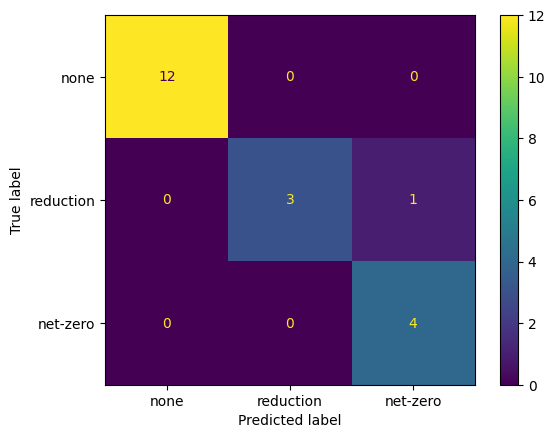

In [65]:
# Additional visualization to understand the results
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print(classification_report(y_num, predictions_1_num))
confMat = confusion_matrix(y_num, predictions_1_num)
disp = ConfusionMatrixDisplay(confusion_matrix=confMat, display_labels=["none", "reduction", "net-zero"])
disp.plot()
plt.show()

Finally, it is always worthwile to look at the misclassifications to understand why the model made a wrong choice. This is your ⭐fourth task⭐.

In [66]:
### PART 4

# Look at the misclassifications. It could reveal interesting model behaviour.
for i, t in enumerate(texts):
  if y_num[i] != predictions_1_num[i]:
    print("Missmatched text:")
    print(t)
    print(f"True Label: {y[i]}")
    print(f"Predicted Label: {predictions_1[i]}")
    print()

Missmatched text:
This year, we want to reduce our emissions in the production by 50%, ultimately aiming for net zero at 2050.
True Label: reduction
Predicted Label: net-zero



**Nice to know**: Other projects have created classifiers for [ESG](https://huggingface.co/ESGBERT), [biodiversity](https://huggingface.co/ESGBERT/EnvironmentalBERT-biodiversity), and [much more](https://huggingface.co/climatebert).

## Solution

In [47]:
# Labelled data point to benchmark the performance
texts, y = zip(
    *[
        ("This reduction against target is the year-to-date position as of 30 June 2020 comparing like-for-like emissions against the same period in 2013.", "reduction"),
        ("Increasing income of the middle classes leads to preference for quality and luxury products as well as differentiated needs including that for personal care items.", "none"),
        ("Our commitment to carbon neutrality by 2035 involves a combination of approaches, including reducing our emissions, migrating energy procurement in favor of renewable and clean energy, and purchasing carbon offsets.", "net-zero"),
        ("Our ambition is to significantly reduce our emissions in the future and this year we achieved carbon neutrality by working with ClimateCare, which has over 22 years of experience in project development, carbon asset development, and the delivery of corporate carbon-offsetting programmes.", "net-zero"),
        ("The goal is to reduce Scope 1 and 2 greenhouse-gas emissions by 20% by 2025 from a 2018 base year.", "reduction"),
        ("We also look at the way banks facilitate financing by others, for example by arranging the issue of green bonds.", "none"),
        ("Looking ahead, we are accelerating action with a long-term goal of ensuring our entire investment portfolio is net carbon neutral by 2050.", "net-zero"),
        ("Forest fires are becoming more frequent due to climate change.", "none"),
        ("We use annual general meetings as another way to monitor and engage with companies to reduce the risks from climate change", "none"),
        ("We believe building a better future involves making climate awareness “business as usual” throughout our organization, starting at the top.", "none"),
        ("We are targetting to achieve net zero by 2055.", "net-zero"),
        ("By reducing energy consumption and GHG emissions, we are not only doing our part to help reduce GHG emissions to the atmosphere but are also helping to mitigate potential impacts from policy or regulatory actions that could put an increased price on carbon emissions.", "none"),
        ("All six capitals are important to our smooth operations and in creating a healthy balance between our economic, social and environmental scorecards.", "none"),
        ("To advance our voting activities on climate change, we created our first climate-change voting policy, which will commence this year.", "none"),
        ("This year, we want to reduce our emissions in the production by 50%, ultimately aiming for net zero at 2050.", "reduction"),
        ("In December 2020, the AUC approved the Electricity Distribution and Natural Gas Distribution requests to defer the compulsory distribution rate increases", "none"),
        ("Scope 1 emissions Scope 1 emissions decreased by 14,01% and remained less than 1% of the overall carbon footprint.", "reduction"),
        ("In the Group, we recognise the benefit of integrating ESG factors into our investment strategy, and in recent years we have taken active steps towards increasing the role that ESG considerations play in determining our investment strategy.", "none"),
        ("Producing greenhouses for agricukture is the heart of our business, and we aim to reduce the materials used significantly.", "none"),
        ("Extreme weather events represent a potential risk.", "none")
    ]
)

In [48]:
import datasets
from transformers import pipeline

# Model and Tokenizer that we are using in this step
model_name = "climatebert/netzero-reduction"
tokenizer_name = "climatebert/distilroberta-base-climate-f"

model = AutoModelForSequenceClassification.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(tokenizer_name, max_len=512)
pipe = pipeline("text-classification", model=model, tokenizer=tokenizer)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

In [54]:
# Look at the output
print(texts[0])
classification = pipe(texts[0])
print(classification) # pipe() always return a list object
# Label only
print(classification[0]["label"])

This reduction against target is the year-to-date position as of 30 June 2020 comparing like-for-like emissions against the same period in 2013.
[{'label': 'reduction', 'score': 0.9421275854110718}]
reduction


In [55]:
### PART 1

# Classify all texts. There is options to do this parallell if you transform the texts to a list(texts) object
# Solution 1: With a for loop (inefficient on scale):
classifications_1 = []
for i in texts:
  temp = pipe(i)
  classifications_1.append(temp[0]) # temp[0] because it pipe always returns a list object with one element (see above)

# Solution 2: transform to list
# classifications_2 = pipe(list(texts))

In [56]:
### PART 2

# Extract labels only from the classifications
predictions_1 = [x["label"] for x in classifications_1]

# transform labels to numbers (not necessary but generally better)
y_num = [0 if x == "none" else 1 if x == "reduction" else 2 for x in y]
predictions_1_num = [0 if x == "none" else 1 if x == "reduction" else 2 for x in predictions_1]

In [67]:
### PART 3

# Calculate accuracy, recall, precision and F1 score
## HINT: We now have a multiple classes (none, reduction, net-zero),
## So for recall, precision and F1 score, we have to specify how we average these classes. For instance:
### 'binary': This is applicable only if targets (y_{true,pred}) are binary.
### 'micro': Calculate metrics globally by counting the total true positives, false negatives and false positives.
### 'macro': Calculate metrics for each label, and find their unweighted mean. This does not take label imbalance into account.
# Example: f1_score(y_true, y_pred, average='macro')

print(f"The accuracy is {accuracy_score(y_num, predictions_1_num)}.")
print(f"The precision is {precision_score(y_num, predictions_1_num, average='macro')}.")
print(f"The recall is {recall_score(y_num, predictions_1_num, average='macro')}.")
print(f"The F1 is {f1_score(y_num, predictions_1_num, average='macro')}.")

The accuracy is None.
The precision is 0.9333333333333332.
The recall is 0.9166666666666666.
The F1 is 0.9153439153439153.


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      0.75      0.86         4
           2       0.80      1.00      0.89         4

    accuracy                           0.95        20
   macro avg       0.93      0.92      0.92        20
weighted avg       0.96      0.95      0.95        20



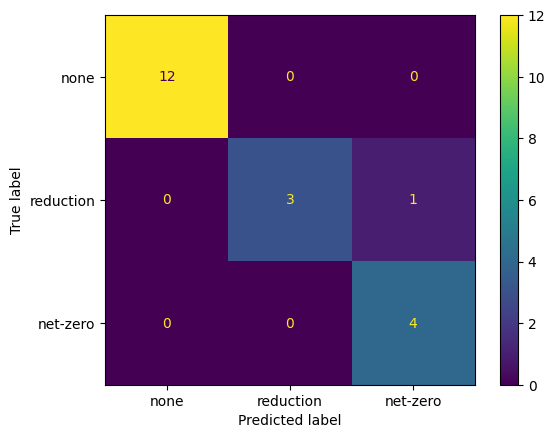

In [68]:
# Additional visualization to understand the results
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print(classification_report(y_num, predictions_1_num))
confMat = confusion_matrix(y_num, predictions_1_num)
disp = ConfusionMatrixDisplay(confusion_matrix=confMat, display_labels=["none", "reduction", "net-zero"])
disp.plot()
plt.show()

In [69]:
### PART 4

# Look at the misclassifications. It could reveal interesting model behaviour.
for i, t in enumerate(texts):
  if y_num[i] != predictions_1_num[i]:
    print("Missmatched text:")
    print(t)
    print(f"True Label: {y[i]}")
    print(f"Predicted Label: {predictions_1[i]}")
    print()

Missmatched text:
This year, we want to reduce our emissions in the production by 50%, ultimately aiming for net zero at 2050.
True Label: reduction
Predicted Label: net-zero



It becomes apparent that the mismatch can happen when both reduction and net zero targets are there at the same time. The model is trained to predict "net-zero" in the case of co-existence of both targets. However, these are model edge cases that are important in the real-world usage.

# Limitations



As introduced, this tutorial shows **"the world before LLMs"**. It is worthwhile to reflect on the limitations to understand the usage potentials. The presented methods are highly efficient and employable on a large scale with comparatively small hardware requirements. Hence, they are also locally employable which mitigates data privacy concerns and limits external reliability.

At the same time, these methods are simple and allow only limited use cases. Specifically, these methods are designed for classification tasks. They serve very well for deciding whether a text is a reduction or net zero target. However, they are limited to assigning labels and cannot argue over text, like modern LLMs would allow. A reasonable way to employ them in many cases is to pre-filter large text corpuses with ML methods, and then possibly analyse these with LLMs.

Another limitation lies in the language corpus that they can be used for. Most BERT-based language models (like ClimateBERT) have only strong performance on the English language. While multilingual BERT models exist, the capabilities will be limited.

In conclusion, this "old world of NLP" is powerful for classification use cases, but the usage or combination with LLMs enhances the field significantly (as demonstrated in the next tutorial).

In [ ]:
# MIT License
#
#@title Copyright (c) 2026 CCAI Community Authors { display-mode: "form" }
#
# Permission is hereby granted, free of charge, to any person obtaining a
# copy of this software and associated documentation files (the "Software"),
# to deal in the Software without restriction, including without limitation
# the rights to use, copy, modify, merge, publish, distribute, sublicense,
# and/or sell copies of the Software, and to permit persons to whom the
# Software is furnished to do so, subject to the following conditions:
#
# The above copyright notice and this permission notice shall be included in
# all copies or substantial portions of the Software.
#
# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
# IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
# FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL
# THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
# LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING
# FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER
# DEALINGS IN THE SOFTWARE.

# NLP Models for Climate Policy Analysis Part 2: Prompts for Sustainable Development Goals

Authors:
*   Daniel Spokoyny, Carnegie Mellon University, dspokoyn@cs.cmu.edu
*   Max Callaghan, Mercator Research Institute on Global Commons and Climate - Berlin, callaghan@mcc-berlin.net
*   Tobias Schimanski, University of Zurich, tobias.schimanski@df.uzh.ch

# Table of Contents

*   [Target Audience](#target-audience)
*   [Overview](#overview)
*   [Contributions](#contributions)
*   [Software Requirements](#software-requirements)
*   [Data Source](#data-source)
*   [Simple Prompt](#simple-prompt)
*   [In-Context Learning Prompts](#icl-prompt)

<a name="target-audience"></a>
# Target Audience

* Climate scientists seeking to use large language models to tackle a domain-specific problem in climate change.
* Data scientists with prior background in deep learning who are interested in building prompt-based large language model classifiers for climate texts.

<a name="Motivation"></a>
# Motivation

The Paris Agreement is an international treaty on climate change that was adopted in 2015.
One of the results of the treaty is that all participating countries are required to submit a Nationally Determined Contribution (NDC) report every five years.
These reports include a variety of vital information, such as the country's current greenhouse gas emissions, their goals for reducing emissions, and the policies they plan to implement to achieve these goals.
Since these reports are written in plain text and can be hundreds of pages long, many questions are difficult to answer automatically, such as:
*   What are the most common policies that countries are implementing to reduce emissions?
*   Which countries are on track to meet their goals?
*   Which countries are falling behind?
*   What are the most common barriers to reducing emissions?

One way to better understand these reports would be to use a common framework to help organize the information.
The Sustainable Development Goals (SDG) framework aims to provide a set of 17 climate goals (e.g. "Affordable and Clean Energy") with even more subgoals (or targets) that can be used to organize the information in the NDC reports.

[Climate Watch](https://www.climatewatchdata.org/) is a project by the World Resources Institute that has manually aligned the unstructured texts of the Nationally Determined Contribution reports to the semi-structured Sustainable Development Goals (SDG) framework.
By doing so, Climate Watch allows for different stakeholders to more easily compare progress across countries and identify which areas need financing, education, policy changes or other resources.

In this tutorial, we will build a prompt-based classifier and use this dataset to evaluate the performance of the classifier.
Since new documents are being updated, a tool that can automatically align NDC reports to the SDG framework would save a lot of time and effort.

# BERT-based classification vs. LLMs for climate policy analysis

In this tutroial, we will use Large Language Models. In previous tutorial, we have seen BERT-based classifiers ("the old world"). BERT-based classifiers are generally more efficient than large language models (LLMs), requiring substantially less computational power and energy for both training and inference, which makes them well suited for large-scale climate policy analysis involving millions of documents. When fine-tuned for specific classification tasks, BERT models often achieve high accuracy while maintaining low operational costs and faster processing speeds. In contrast, LLMs offer greater flexibility, as they can perform a wide range of tasks including classification, summarization, reasoning, and information extraction. LLMs can do this without requiring task-specific retraining. Consequently, while BERT-based classifiers are often preferable for scalable and resource-efficient policy monitoring, LLMs are better suited for more complex analytical tasks that demand contextual understanding and adaptability.

<a name="overview"></a>
# Overview: OpenAI Classification Extraction with Prompt Based In-Context Learning

In this tutorial we will use the OpenAI Large Language Models (LLMs) to classify climate policy documents.
For the data we will work with the Nationally Determined Contributions (NDCs) documents from the Paris Climate Agreement. As the model we will use OpenAI's 'gpt-4o-mini-2024-07-18' (small and efficient ChatGPT model) and attempt to use carefully crafted prompts to classify sentences from our dataset.

While in the previous tutorial we were focused on training supervised NLP models for text classification, with the advent of LLMs a more recent paradigm, prompting, has emerged. Prompting allows for interfacing with a trained machine learning model using text as input and text as output.

The rest of the tutorial is organized as follows

(1) **Dataset**: We are going to load the dataset and get it ready for prompt classification. \
(2) **Prompting**: We are going to construct a simple prompt and use it to classify sentences. \
(3) **In-Context-Learning (ICL)**: We are going to add to the prompt in-context learning examples and also increase the context of the input text.


<a name="contributions"></a>
# Contributions

Through introductory presentations and colab notebooks, we aim to expose the participants to:

(a) **Dataset**: Outlining a dataset of national climate action plans with corresponding annotations to the Sustainable Development Goals framework. \
(b) **Prompting**: Designing prompts with in-context learning to perform novel text classification tasks. \
(c) **LLMs**: Using large language models (LLMs) via python web-based APIs.

<a name="software-requirements"></a>
# Software Requirements
This notebook requires the following libraries:
*   datasets (pip)
*   openai (pip)

`datasets` is a library which we will use to download the data required.
`openai` is a library from which we can access large language models via a python API. To use the model, you will need to sign up for an OpenAI Account (http://platform.openai.com/signup) and get an API key pasted below.


In [1]:
# We need to install the following packages to run the code in this notebook
# %%capture
!pip install datasets
!pip install openai
!pip install -U llama-index llama-index-readers-file llama-index-embeddings-openai pymupdf # ATTENTION: You may need to restart the session to load these successfully

In [2]:
# Import libraries
import openai
from openai import OpenAI
import json
from huggingface_hub import hf_hub_download
from datasets import load_dataset

In [3]:
# This here is how we will load the SDG dataset from the HuggingFace Hub.
# It has already been preprocessed for you to use.
dataset = load_dataset("dspoka/sdg-single")

# Here we will transform the dataset into a pandas dataframe
df_full = dataset['full'].to_pandas()

print(f'The dataset has {df_full.shape[0]} rows and {df_full.shape[1]} columns')
print(f'The columns are: {df_full.columns.values}')
df_full.head()

README.md:   0%|          | 0.00/777 [00:00<?, ?B/s]

data/full-00000-of-00001-c9b480cdebf4ea5(…): reconstructing file:   0%|          |  0.00B /  810kB            

data/full-00000-of-00001-c9b480cdebf4ea5(…): downloading bytes:           |  0.00B            

Generating full split:   0%|          | 0/14219 [00:00<?, ? examples/s]

The dataset has 14219 rows and 13 columns
The columns are: ['iso3' 'country' 'goal' 'target' 'text' 'status' 'sector' 'response'
 'infotype' 'start' 'end' 'filename' '__index_level_0__']


,iso3,country,goal,target,text,status,sector,response,infotype,start,end,filename,__index_level_0__
0,AFG,Afghanistan,12,12.2,Reduce rural peoples’ dependence on fuel for c...,future,energy efficiency,mitigation,needs_and_gaps,28031.0,28096.0,AFG-first_ndc-EN.html,0
1,AFG,Afghanistan,1,1.5,Reducing vulnerability of the country and its ...,future,health,adaptation,action,12482.0,12648.0,AFG-first_ndc-EN.html,1
2,AFG,Afghanistan,13,13.1,Reducing vulnerability of the country and its ...,future,health,adaptation,action,12482.0,12648.0,AFG-first_ndc-EN.html,2
3,AFG,Afghanistan,15,15.2,Regeneration of at least 40% of existing degra...,not_specified,not_specified,not_specified,not_specified,19765.0,19906.0,AFG-first_ndc-EN.html,3
4,AFG,Afghanistan,7,7.2,"Renewable energy, entry costs support, access ...",future,renewable energy,mitigation,needs_and_gaps,27461.0,27532.0,AFG-first_ndc-EN.html,4


<a name="data-source"></a>
# Understanding the SDG Dataset

The important columns for us to know are 'goal', and 'text'.
- The 'text' column is the raw text that was annotated in the NDC documents. We will feed this into our model and use it to predict the the label.
- The 'goal' column is the SDG goal. We will use this as our main label for prediction.
- Each SDG 'goal' also has sub-goals or 'target' as the name of the column.
- Currently, if you take a look the goals they are ["1",...,"17"]. Goal "12" may have a target "12.2".
- What does goal "12" stand for exactly? Well for this, we need to take a look at the metadata.
- Below, is an image that shows the 2030 progerss for the SDG goals and targets.
![SDG Goals](https://unece.org/sites/default/files/styles/max_1300x1300/public/2021-03/Graphic%20EN%20_PR_SDG%20Report.png?itok=Mwuuj3c7)


In [4]:
def unpack_and_explain_metadata(metadata):
    '''Args:
        metadata: dictionary containing the metadata for the dataset.
    Returns:
        goal_idx_2_description: dictionary mapping goal index to the text description of the goal.
        goal_idx_2_goal_number: dictionary mapping goal index to the goal number. The goal number is what is currently in the dataset frame.
        target_idx_2_description: dictionary mapping target index to the text description of the target.
        target_idx_2_goal_idx: dictionary that maps a target index to the goal index. There are multiple targets per goal.
        target_idx_2_target_number: dictionary that maps a target index to the target number. The target number is what is currently in the dataset frame.

    '''
    goal_idx_2_description = metadata['goal_idx_2_description']
    goal_idx_2_description = {int(k):v for k,v in goal_idx_2_description.items()}

    goal_idx_2_goal_number = metadata['goal_idx_2_goal_number']
    goal_idx_2_goal_number = {int(k):v for k,v in goal_idx_2_goal_number.items()}

    target_idx_2_description = metadata['target_idx_2_description']
    target_idx_2_description = {int(k):v for k,v in target_idx_2_description.items()}

    target_idx_2_goal_idx = metadata['target_idx_2_goal_idx']
    target_idx_2_goal_idx = {int(k):int(v) for k,v in target_idx_2_goal_idx.items()}

    target_idx_2_target_number = metadata['target_idx_2_target_number']
    target_idx_2_target_number = {int(k):v for k,v in target_idx_2_target_number.items()}

    return goal_idx_2_description, goal_idx_2_goal_number, target_idx_2_description, target_idx_2_goal_idx, target_idx_2_target_number


# We will also download the metadata for the dataset from the HuggingFace Hub.
filepath = hf_hub_download(repo_id="dspoka/sdg-single", filename="metadata.json", repo_type="dataset")
with open(filepath) as f:
    metadata = json.load(f)

# In this method we will unpack the dictionaries and explain what each of the metadata means
goal_idx_2_description, goal_idx_2_goal_number, target_idx_2_description, target_idx_2_goal_idx, target_idx_2_target_number = unpack_and_explain_metadata(metadata)

metadata.json:   0%|          | 0.00/33.4k [00:00<?, ?B/s]

### So lets look at a row of our dataset df_full and see how to use the metadata to understand it.

Let's understand the dataset. It holds texts from a document that are assigned with goal labels. Beyond that, there is meta information like country or sector that contextualise the data.

In [5]:
# first row
print(df_full.iloc[0])
# and here is the text of the first row:
print('Text', df_full.iloc[0]['text'])

iso3                                                               AFG
country                                                    Afghanistan
goal                                                                12
target                                                            12.2
text                 Reduce rural peoples’ dependence on fuel for c...
status                                                          future
sector                                               energy efficiency
response                                                    mitigation
infotype                                                needs_and_gaps
start                                                          28031.0
end                                                            28096.0
filename                                         AFG-first_ndc-EN.html
__index_level_0__                                                    0
Name: 0, dtype: object
Text Reduce rural peoples’ dependence on fuel for cook

### Looking at row
- We see that this piece of text is from the NDC of the country "Afghanistan" and from this particular file: AFG-first_ndc-EN.html
- We also see some other topic labels, such that this is about the "energy efficiency" sector, is a type of mitigation Climate Response, and that its current implementation status is "future".
- We also see that the Sustainable Development Goals (SDG) goal is "12" and target is "12.2".
- Note idx or the index is 0-indexed for both goal_idx and target_idx.


In [6]:
goal_number = "12"
goal_idx = None
for k,v in goal_idx_2_goal_number.items():
    if v == "12":
        goal_idx = k
        break

print(f'There are {len(goal_idx_2_description)} goals in the dataset.')
print(f'The "{goal_number}" goal has this text description: {goal_idx_2_description[goal_idx]}')

There are 17 goals in the dataset.
The "12" goal has this text description:  Ensure sustainable consumption and production patterns


We can also find all targets or subgoals that belong to this goal in specific (just for understanding, we will not use these targets later on).

In [7]:
# Find all target_ids that belong to goal 0
target_ids = []
for target_id, goal_id in target_idx_2_goal_idx.items():
    if goal_id == goal_idx:
        target_ids.append(target_id)

# And now lets print all the descriptions of the targets that belong to goal 0
for target_id in target_ids:
    print(f'Target {target_id} has the following description: {target_idx_2_description[target_id]}')

Target 0 has the following description: By 2030, achieve the sustainable management and efficient use of natural resources
Target 9 has the following description: By 2030, substantially reduce waste generation through prevention, reduction, recycling and reuse
Target 20 has the following description: Implement the 10-year framework of programmes on sustainable consumption and production, all countries taking action, with developed countries taking the lead, taking into account the development and capabilities of developing countries
Target 21 has the following description: By 2020, achieve the environmentally sound management of chemicals and all wastes throughout their life cycle, in accordance with agreed international frameworks, and significantly reduce their release to air, water and soil in order to minimize their adverse impacts on human health and the environment
Target 29 has the following description: By 2030, ensure that people everywhere have the relevant information and aw

<Axes: xlabel='goal'>

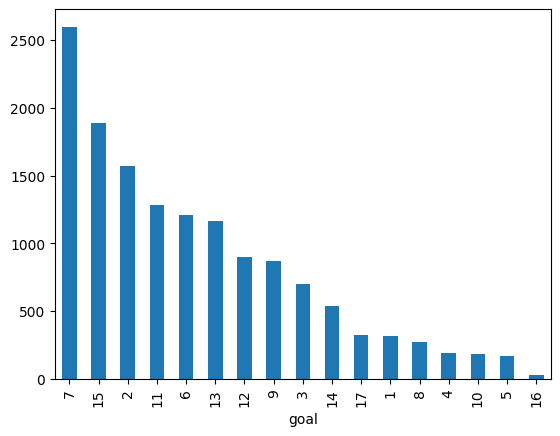

In [8]:
# Lets also plot the histogram of goals in the dataset
df_full['goal'].value_counts().plot(kind='bar')

<a name="simple-prompt"></a>
## Using prompting to classify the text into the correct SDG goal.
In this section we will set up the classification task that we wish to perform.
- We will feed in the text from the NDC and have the model predict the corresponding SDG goal.
- **Unlike in the previous tutorial where we fine-tuned a classifier on supervised data, here we will adopt the strategy of prompting a Large Language Model (LLM) to perform this in a zero-shot and few-shot manner.**
- Zero-shot prompting is without examples of labelled text and few-shot prompting is with examples.
- First let's do a quick review so that we can understand what prompting is and how it works.


## Large Language Models (LLMs) and Prompting
- In the previous tutorial, we fine-tuned a classification head on top of a pretrained transformer model.
- Given a sentence the model outputted a vector of dimension 'd' and we added new parameter weights (classification head) to map this vector to a vector of dimension 'k' where 'k' is the number of classes.
- Since these classifier's parameters are randomly initialized, we needed to train them on supervised data in order to learn the correct mapping.
- This may be limiting if we have too little labeled data or its too expensive to label data.

What if instead of introducing new parameters we could use the same underlying transformer model to also perform the classification task?


## Enter Prompting
- LLMs are typically pretrained on large amounts of unlabeled text with a self-supervised objective: predicting the next word.
- The initial idea of prompting can then be thought as: "How can we change this classification task such that it falls naturally to next word prediction?"
- Suppose we start with a sentiment classification sentence like "I loved this movie, it was a blast!" where the true label is "positive".
- We can then add a prompt or a template of the form "{Movie Review}. This movie is {sentiment}"
    - input to model: "I loved this movie, it was a blast! This movie is"
    - and we can compare the next word prediction probability of the label "positive" versus "negative".
- Whichever is higher is the label we choose.
- This is a simple example of prompting, where we reframed sentiment classification to fit with the next word prediction which allows us to use the same pretrained model without any additional parameters.

### Current LLMs and Prompting
- The simple example above gives intuition for simple prompting but in practice current LLMs are much more flexible with the types of prompts that can be used.
- They have been trained on extra datasets for following instructions so that they can perform tasks where the answers don't have to be mapped directly to the next word prediction.
- In this first section, we are going to build a simple instruction prompt which will describe our SDG Goal classification task to the model.


In [9]:
import os
import pandas as pd
import numpy as np
import random

# set seeds for reproducibility
np.random.seed(42)
random.seed(42)


# lets setup some global variables

# for goal prediction this will be the number of classes
N_PRED_CLASSES = len(goal_idx_2_goal_number)
# this will signify to the model the start of the input text
INPUT_MARKER = 'Input Text'

# This dictionary just contains the names of the columns to slightly longer names that are easier to understand.
column_names = {'goal': 'Sustainable Development Goal', 'target': 'Subgoal', 'status': 'Status', 'sector': 'Sector', 'response': 'Climate Response', 'infotype': 'Information Type'}

### Constructing the Prompt
- We are going to construct the prompt in two parts: instructions at the top and the input text to classify at the bottom.

In [10]:
# for now we will skip the special_token as well as the what the "context" column is.
def build_instruction(pred_column, obs_column):
    ''' Args:
            pred_column (str): the column that we are predicting
            obs_column (str): the column that we are observing (e.g. text, context)
        Returns:
            prompt (str): the prompt that will be used to query the model

    '''
    # describe what the model's input, task and class options are.
    prompt = f'You are provided with an input text **{INPUT_MARKER}**. Your task is to predict the {column_names[pred_column]} ({pred_column}) out of the following {N_PRED_CLASSES} options:\n'

    # for now we will assume that we are predicting the goal column
    assert pred_column == 'goal'
    goal_number_2_goal_idx = {v: k for k, v in goal_idx_2_goal_number.items()}

    # Here we are building a dictionary that maps the goal number to the goal description
    goal_number_2_goal_description = {k:goal_idx_2_description[v] for k, v in goal_number_2_goal_idx.items()}

    # we sort this according to the goal number
    sorted_keys = sorted(int(k) for k in list(goal_number_2_goal_description.keys()))
    sorted_keys = [str(k) for k in sorted_keys]

    # build a list of strings where each string is the goal number and the goal description
    values = [f'{key}:{goal_number_2_goal_description[key]}' for key in sorted_keys]
    name = column_names[pred_column]
    # and we join each goal/description with a new line to the intruction
    prompt += name + '\n' +"\n".join(values) + "\n\n"
    return prompt

In [11]:
# Create an example
prompt_example = build_instruction(pred_column='goal', obs_column='text')
print(prompt_example)

You are provided with an input text **Input Text**. Your task is to predict the Sustainable Development Goal (goal) out of the following 17 options:
Sustainable Development Goal
1: End poverty in all its forms everywhere
2: End hunger, achieve food security and improved nutrition and promote sustainable agriculture
3: Ensure healthy lives and promote well-being for all at all ages
4: Ensure inclusive and equitable quality education and promote lifelong learning opportunities for all
5: Achieve gender equality and empower all women and girls
6: Ensure availability and sustainable management of water and sanitation for all
7: Ensure access to affordable, reliable, sustainable and modern energy for all
8: Promote sustained, inclusive and sustainable economic growth, full and productive employment and decent work for all
9: Build resilient infrastructure, promote inclusive and sustainable industrialization and foster innovation
10: Reduce inequality within and among countries
11: Make citi

In [12]:
def build_single_prompt(row, pred_column, obs_column, test_input_only=False):
    ''' Args:
        row (pd.Series): a row from the dataframe
        obs_column (str): the column that we are observing (e.g. text, context)
        test_input_only (bool):
            - if True, only return the input text
                - This is used for the test example.
            - if False, return the input text and the correct answer
                - This will be for in-context learning
        Returns:
            prompt (str): the second portion of the prompt
    '''
    prompt = f'\n**{INPUT_MARKER}**: {row[obs_column]}\n'
    if test_input_only:
        return prompt

    value = row[pred_column]
    prompt += f'{pred_column}:{value}\n'
    prompt += '\n'
    return prompt

In [13]:
# Create an example
prompt_example = build_instruction(pred_column='goal', obs_column='text')

# Sample a random row from the dataframe to use as a test example
random_test_row = df_full.sample(1).iloc[0]
test_input = build_single_prompt(random_test_row, pred_column='goal', obs_column='text', test_input_only=True)

prompt_example += "Given these categories, please classify the following **Input Text** by only answering with the single number of the goal:"
prompt_example += test_input
prompt_example += f'goal:'
# Here we have the full instruction and prompt for the model
print(prompt_example)

You are provided with an input text **Input Text**. Your task is to predict the Sustainable Development Goal (goal) out of the following 17 options:
Sustainable Development Goal
1: End poverty in all its forms everywhere
2: End hunger, achieve food security and improved nutrition and promote sustainable agriculture
3: Ensure healthy lives and promote well-being for all at all ages
4: Ensure inclusive and equitable quality education and promote lifelong learning opportunities for all
5: Achieve gender equality and empower all women and girls
6: Ensure availability and sustainable management of water and sanitation for all
7: Ensure access to affordable, reliable, sustainable and modern energy for all
8: Promote sustained, inclusive and sustainable economic growth, full and productive employment and decent work for all
9: Build resilient infrastructure, promote inclusive and sustainable industrialization and foster innovation
10: Reduce inequality within and among countries
11: Make citi

As you probably know from your interactions with LLMs (like ChatGPT), you can also change the text above and add more or less detail. The prompt is really flexible. Think about a policy analysis use case where you want to give your own definitions. This is possible by "just" changing the prompt. This way, your NLP workflow can adapt to your policy anlysis setting.

### Let's get model predictions for this test example now

To use OpenAI models, you need to create an acoount and an API KEY. Follow [this tutorial](https://www.merge.dev/blog/chatgpt-api-key) to do so.

In [14]:
# To use the model, you will need to sign up for an OpenAI Account (http://platform.openai.com/signup) and get an API key pasted below.
# so we will use this particular model
API_KEY="sk-"
MODEL_NAME = "gpt-4o-mini-2024-07-18"
CLIENT = OpenAI(api_key=API_KEY)

def get_model_response(CLIENT, MODEL, prompt):
  completion = CLIENT.chat.completions.create(
    model=MODEL,
    messages=[
      {"role": "user", "content": prompt}
    ],
    temperature=0
  )

  return completion.choices[0].message.content

While you don't need to understand every function, an important detail here is the "temperature=0" line. the temperature parameter steers how deterministic a model is. When the parameter is close to 0, the model becomes very deterministic. This means, the output stays the same across runs. When the parameter goes towards 1, the model becomes more creative and less reproducible. For our task, we almost always want the parameter to be 0 because of reproducibility.

In [20]:
# For now we can just test the function
example_pred = get_model_response(CLIENT, MODEL_NAME, prompt_example)
print(example_pred)

AuthenticationError: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}

Now, we split our data in training, validation and testing data to clearly differentiate between data points that may inform our prompt and those that evaluate the final models.

In [18]:
from sklearn.model_selection import train_test_split

def make_new_splits(df):
    '''We want to make sure that we split into train/val/test by documents and not by sentences. This helps us ensure that we aren't overfitting to a particular document/country.
    Suppose (hyperbolically) that each document only had one SDG class. Then if we split by sentence, the model may overfit by first predicting which country the sentence is from, and then predicting the SDG goal based on that country. This is undesirable and so it is better to split by documents.
    Args:
        df (pd.DataFrame): the full dataframe
    Returns:
        df_train (pd.DataFrame): the training dataframe
        df_val (pd.DataFrame): the validation dataframe
        df_test (pd.DataFrame): the test dataframe
    '''
    seed = 42
    filenames = df['filename'].unique()
    train_filenames, test_filenames = train_test_split(filenames, test_size=0.4, random_state=seed)
    val_filenames, test_filenames = train_test_split(test_filenames, test_size=0.5, random_state=seed)
    print(len(train_filenames), len(val_filenames), len(test_filenames))
    df_train = df[df['filename'].isin(train_filenames)]
    df_val = df[df['filename'].isin(val_filenames)]
    df_test = df[df['filename'].isin(test_filenames)]
    print(f'train: {df_train.shape}\tval: {df_val.shape}\ttest: {df_test.shape}')
    return df_train, df_val, df_test

In [21]:
df_train, df_val, df_test = make_new_splits(df_full)

128 43 43
train: (9611, 13)	val: (2507, 13)	test: (2101, 13)


Now, prompts that are not used in the evaluation of our LLM-based classifier can be used in the prompt as examples. This is call few-shot prompting or also in-context learning (ICL).

<a name="icl-prompt"></a>
## In-Context Learning Prompts
- Before running and evaluating the model's performance, let's improve our prompt by adding in-context learning (ICL) examples.
- So after we describe the instructions for the task, we will now add a few input/output examples that we want the model to match.
- We will use a new function "in_context_prompt" which is simply a wrapper around the previous functions we used.

In [22]:
def in_context_prompt(df, pred_column, obs_column, num_samples=3):
    '''
        Args:
            df (pd.DataFrame): the dataframe that we are sampling from
            pred_column (str): the column that we are predicting
            obs_column (str): the column that we are observing
            num_samples (int): the number of in-context learning samples to add to the prompt
        Returns:
            prompt (str): the full prompt for the model
    '''
    # as before we build the instruction
    prompt = build_instruction(pred_column, obs_column)

    # for each icl example we sample a random row from the dataframe
    prompt += "\nYou are also provided with the following examples of classifications:\n[BEGIN OF EXAMPLES]\n"
    for i in range(num_samples):
        row = df.sample(1)
        # note that we set test_input_only to false since we want to include the goal label for the icl examples
        prompt += build_single_prompt(row.iloc[0], pred_column, obs_column, test_input_only=False)
    prompt += "[END OF EXAMPLES]\n"
    return prompt

In [23]:
# We need to split df_full into train/val such that the ICL examples dont overlap with the test example
# df_train = df_full.sample(frac=0.8, random_state=42)
# df_val = df_full.drop(df_train.index)

icl_prompt_example = in_context_prompt(df_train, pred_column='goal', obs_column='text', num_samples=5)

# sample a random row from the dataframe to use as a test example
random_test_row = df_val.sample(1).iloc[0]
test_input = build_single_prompt(random_test_row, pred_column='goal', obs_column='text', test_input_only=True)

icl_prompt_example += "\nGiven these categories and examples, please classify the following **Input Text**  by only answering with the single number of the goal:"
icl_prompt_example += test_input
icl_prompt_example += f'{"goal"}:'
print(icl_prompt_example)
print('-'*80)
print('True Goal', random_test_row['goal'])

You are provided with an input text **Input Text**. Your task is to predict the Sustainable Development Goal (goal) out of the following 17 options:
Sustainable Development Goal
1: End poverty in all its forms everywhere
2: End hunger, achieve food security and improved nutrition and promote sustainable agriculture
3: Ensure healthy lives and promote well-being for all at all ages
4: Ensure inclusive and equitable quality education and promote lifelong learning opportunities for all
5: Achieve gender equality and empower all women and girls
6: Ensure availability and sustainable management of water and sanitation for all
7: Ensure access to affordable, reliable, sustainable and modern energy for all
8: Promote sustained, inclusive and sustainable economic growth, full and productive employment and decent work for all
9: Build resilient infrastructure, promote inclusive and sustainable industrialization and foster innovation
10: Reduce inequality within and among countries
11: Make citi

### That's it! We now have a prompt with the instruction, 5 in-context learning examples, and the input text to classify.
- For evaluation we will calculate the accuracy of the model on the test set.
- Since each sentence can have **multiple** SDG goals labeled, we will calculate whether the model can predict **any** of the correct labels.


In [24]:
def calculate_accuracy(true_, pred_):
    ''' Calculate accuracy of predictions
        There could be multiple true labels for each example
        There is only one predicted label for each example
        Args:
            true_ (list): list of lists of true labels
            pred_ (list): list of predicted labels
        Returns:
            accuracy (float): the accuracy of the predictions
    '''
    assert len(true_) == len(pred_)
    # accuracy = sum([t==p for t, p in zip(true_, pred_)])/len(true_) # this is when there is only one true label
    right = 0
    for t, p in zip(true_, pred_):
        assert type(t) == list
        if p in t:
            right += 1
    return right/len(true_)

def most_common(lst):
    ''' helper function to select the most common element in a list
        Args:
            lst: list of elements
        Returns:
            most common element in the list
    '''
    # print('lst', lst)
    # print('type(lst)', type(lst)
    if type(lst) == str:
        return lst
    return max(set(lst), key=lst.count)

### Finally we are going to put this all together into a run_eval function
- This is the function that we will pass different arguments to in order to run different experiments.

In [25]:
def run_eval(df_train, df_test, pred_column, obs_column, num_samples, num_icl, CLIENT, MODEL):
    '''
        Args:
            df_train (pd.DataFrame): the dataframe that we are sampling from for ICL examples
            df_test (pd.DataFrame): the dataframe that we are sampling from for test examples
            pred_column (str): the column name that we are predicting
            obs_column (str): the column name that we are observing
            num_samples (int): the number of test examples to evaluate on
            num_icl (int): the number of in-context learning examples to include in the prompt
            CLIENT (str): OpenAI model client
            MODEL (str): used OpenAI model
        Returns:
        true_ (list): list of lists of true labels
        pred_ (list): list of predicted labels
        test_texts (list): list of the test examples
        test_prompt (str): the full last prompt used for the model for debugging/sanity check purposes
        test_ids (list): list of the ids of the test examples (this is useful such that the same test examples are not labeled multiple times)


    '''
    # Note if we set the test_prompt outside the for loop here
    # Then are using the same ICL prompt for all test examples.
    # If we do so, we can then more easily get batch predictions from the API
    # However, if we sample unlucky ICL examples, then the model may not perform as well.
    # So we will leave it inside the for loop for now.
    # test_prompt = in_context_prompt(df_train, pred_column, obs_column, num_icl)
    ################################################################################

    # Recall that one piece of text has many goals and targets.
    # So in our dataframe there multiple rows which have the same text.
    # This line to group makes sure that only unique texts are present.
    # It also aggregates the multiple goals for the same text into a list.
    df_group = df_test.groupby(obs_column, as_index=False).agg(lambda x: list(x))

    ######## Another strategy would be to use majority SDG goal
    # assert df_group[pred_column].apply(lambda x: type(x) == list).all()
    # df_group['majority'] = df_group[pred_column].apply(lambda x: most_common(x))
    ################################################################################


    # make sure that the text column is a list and only has one unique element
    if obs_column != 'text':
        assert df_group['text'].apply(lambda x: len(set(x)) == 1).all()
        df_group['text'] = df_group['text'].apply(lambda x: x[0])
        assert len(set(df_group['text'])) == 1

    # Sample num_samples test examples
    test_rows = df_group.sample(num_samples)

    # Get the test_ids
    test_ids = test_rows['__index_level_0__'].tolist()

    true_ = []
    pred_ = []
    test_texts = []
    # For each test example, get the model prediction
    for i in range(num_samples):
        test_row = test_rows.iloc[i]
        text = test_row['text']
        true = test_row[pred_column]
        assert type(true) == list

        test_prompt = in_context_prompt(df_train, pred_column, obs_column, num_icl)
        test_input = build_single_prompt(test_row, pred_column, obs_column, test_input_only=True)

        test_prompt += "\nGiven these categories and examples, please classify the following **Input Text** by only answering with the single number of the goal:"
        test_prompt += test_input
        test_prompt += f'{pred_column}:'
        #print(test_prompt)

        test_texts.append(text)
        true_.append(true)

        response = get_model_response(CLIENT, MODEL, test_prompt)
        pred = response
        pred_.append(pred)

    return true_, pred_, test_texts, test_prompt, test_ids

In [26]:
true_, pred_, test_texts, test_prompt, test_ids = run_eval(df_train, df_val, pred_column='goal', obs_column='text', num_samples=10, num_icl=5, CLIENT=CLIENT, MODEL=MODEL_NAME)

accuracy = calculate_accuracy(true_, pred_)
print('accuracy', accuracy)
print()

AuthenticationError: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}

### Checking Model Predictions
- Recall that since we are using prompting we are interpreting the model's textual output as a label.
- We are mapping the model's output of "3" to the label which corresponds to SDG Goal "3".
- But what if the model outputs a label outside of the range of our labels? or even fails to output a number but instead outputs a different word?
- We can check for these cases and see how often they occur.

In [27]:
def check_predictions(pred_):
    ''' - Sanity check to make sure that all predictions are integers
        - and also are indexed in between the number of classes
        Args:
            pred_ (list): list of predicted labels
        Returns:
            None
    '''
    count_not_digit = 0
    count_in_range = 0
    for p in pred_:
        if not p.isdigit():
            count_not_digit += 1
        elif int(p) not in list(range(1, 1+N_PRED_CLASSES)):
            count_in_range += 1
        # assert p.isdigit()
        # assert int(p) in list(range(1, 1+N_PRED_CLASSES))
    print('count_not_digit', count_not_digit)
    print('count_in_range', count_in_range)

In [28]:
check_predictions(pred_)

NameError: name 'pred_' is not defined

The large models from OpenAI have been tuned specifically to follow complex prompts or instructions. This is one reason why there should generally be a good prediction performance. However, the task is non-trivial given that we have 17 categories that are not always clearly differntiable.

To give an intuition of how complex the task is, we can compare it with the performance of randomly guessing for a 1000 times:

In [ ]:
def plot_random_histogram(true_):
    ''' Plot a histogram of accuracies of a random classifier
        Args:
            true_ (list): list of lists of true labels
        Returns:
            None
    '''
    num_trials = 1000
    random_accuracies = []
    for i in range(num_trials):
        random_pred = np.random.choice(list(range(1, 1+N_PRED_CLASSES)), size=len(true_))
        random_pred = [str(x) for x in random_pred]

        random_accuracy = calculate_accuracy(true_, random_pred)

        random_accuracies.append(random_accuracy)
    # histogram
    import matplotlib.pyplot as plt
    plt.hist(random_accuracies, bins=20)
    avg_acc = np.mean(random_accuracies)

    # this is how a random uniform classifier would perform
    print(f'avg random acc: {avg_acc}')

In [ ]:
plot_random_histogram(true_)

In conclusion, the models are much better than a random baseline.

# Exercise 2

⭐ **YOUR TURN!** ⭐  So far, we saw the prompt as a given. However, the prompt design highly influences the outcome.

**REMINDER**: To use OpenAI models, you need to create an acoount and an API KEY. Follow [this tutorial](https://www.merge.dev/blog/chatgpt-api-key) to do so.

In [ ]:
API_KEY="Your API Key"


In [ ]:
MODEL_NAME = "gpt-4o-mini-2024-07-18"
CLIENT = OpenAI(api_key=API_KEY)

This is code for visualizing the output.

In [ ]:
from IPython.core.display import display, HTML

def visualize(answer):
  answer_html = f"<p>{answer}</p>".replace("\n", "</p><p>")
  in_html = f"""
            <h3>Output:</h3>
            {answer_html}
            """
  display(HTML(in_html))

Consider the following examples (from [Financial Times](https://www.ft.com/content/38be4231-21cf-46e3-8b6a-88a4e923f01c), [Reuters](https://www.reuters.com/business/finance/prosecutors-visit-dws-offices-again-over-alleged-greenwashing-2024-02-01/) and [DWS Homepage](https://www.dws.com/en-ch/solutions/sustainability/)):

In [ ]:
### Statements about DWS ESG practices

example_sources = """
SOURCE REUTERS:
U.S. regulators said in September that DWS was due to pay $25 million to settle
charges over misstatements regarding its environmental, social, and governance (ESG)
investing and failures in policies designed to prevent money laundering.

------

SOURCE Financial Times:
DWS made misleading statements in its 2020 annual report over the size of its ESG assets.
A executive claimed she was fired after informally raising her concerns internally and
subsequently filed a formal whistleblower complaint.

------
SOURCE DWS:
DWS has long recognized the importance of ESG factors for investors and was among the early
signatories of the United Nations-backed Principles for Responsible Investment (PRI) in 2008.
"""

In this exercise, we want to learn about the power of prompt engineering. Prompting engineering can be seen as a iterative process of refining the instruction to a model. We want to iteratively distill judgements on DWS' ESG practices through the given sources. We start by creating a summary. Thereby, we want to follow general prompt engineering guidelines.

***1. Write clear and specific instructions***

The effort you put in equals to the results you get out.

***2. Structure the text: Use Delimiters***

For the model to understand content correctly, it is extremely helpful to use delimiters to separate texts from each other (see for instance "-----" above).

In [ ]:
# Start with a summary
prompt = f""" Your are a ESG analyst with the target of analysing the company DWS.

You are provided with the following sources about the company delimited in <>.

<{example_sources}>

Please summarise the companies' integration of ESG.
"""

answer = get_model_response(CLIENT, MODEL_NAME, prompt)
visualize(answer)

This is a good summary for this one case but if you have much more sources or companies, the outcome may need to be refined.

***3. Iteratively refine the task***

Prompt Engineering is essentially a process of iteratively refining the task for your need.

Your ⭐first task⭐ is to transform the output in a list format of negative and positive aspects. There is no golden solution to these tasks, you can play around with alternatives that you like.

In [ ]:
### TASK 1

# Positive and negative points
prompt = ### YOUR CODE HERE ###

answer = get_model_response(CLIENT, MODEL_NAME, prompt)
visualize(answer)

***4. Convert the output into a structured format***

Depending on the task and evaluation strategy, different formats might be helpful.

Your ⭐second task⭐ is to transform the list of negative and positive aspects into JSON format (if you don't know, just ask the model to produce it).

In [ ]:
### TASK 2

# Positive and negative points in JSON
prompt = ### YOUR CODE HERE ###

answer = get_model_response(CLIENT, MODEL_NAME, prompt)
visualize(answer)

***5. Use vast model capabilities***

Apart from summarization or question answering, LLMs typically possess vast capabilities like reflecting on the output or providing helpful feedback.

Your ⭐third task⭐ is to use the models capabilities to reflect on the outcome. Ask the model to critically question the companies' ESG statements.

In [ ]:
### TASK 3

# Positive and negative points in JSON
prompt = ### YOUR CODE HERE ###

answer = get_model_response(CLIENT, MODEL_NAME, prompt)
visualize(answer)

***Further ressources:***

Of course, there is much more depth to Prompt Engineering. The following sources could help to refine knowledge further:
- Free course on [Prompt Engineering](https://learn.deeplearning.ai/chatgpt-prompt-eng/)
- Article on [Prompt Engineering 101]( https://hackernoon.com/prompt-engineering-101-i-unveiling-principles-and-techniques-of-effective-prompt-crafting)

## Solution

**IMPORTANT**: There is no golden solution to these tasks, you can play around with alternatives that you like.

In [ ]:
### TASK 1

# Positive and negative points
prompt = f""" Your are a ESG analyst with the target of analysing the company DWS.

You are provided with the following sources about the company delimited in <>.

<{example_sources}>

Please summarise the companies' integration of ESG the positive and negative aspects of DWS' activities.
For this, create two lists that contain short bullet points.
"""

answer = get_model_response(CLIENT, MODEL_NAME, prompt)
visualize(answer)

In [ ]:
### TASK 2

# Positive and negative points in JSON
prompt = f""" Your are a ESG analyst with the target of analysing the company DWS.

You are provided with the following sources about the company delimited in <>.

<{example_sources}>

Please summarise the companies' integration of ESG the positive and negative aspects of DWS' activities.
For this, create two lists that contain short bullet point summaries.

Format this output in a JSON format with the keys "positive_asepects" and "negative_aspects".
"""

answer = get_model_response(CLIENT, MODEL_NAME, prompt)
visualize(answer)

In [ ]:
### TASK 3

# Positive and negative points in JSON
prompt = f""" Your are a ESG analyst with the target of analysing the company DWS.

You are provided with the following sources about the company delimited in <>.

<{example_sources}>

Please critically reflect on the statements of DWS in the light of all sources.
How trustworthy are their statements?
End your judgment with a score from 1 (not trustworthy) to 10 (very trustworthy).
"""

answer = get_model_response(CLIENT, MODEL_NAME, prompt)
visualize(answer)

# Exercise 3

⭐ **YOUR TURN!** ⭐ again. Now, you should have a feeling for creating a prompt. Furthermore, we experimented with argueing over content - be it classification, summarization or structured output.

However, until now, we provided the external content. What if we want to analyse full reports with LLMs? For this, we will use a technique called Retrieval Augmented Generation (RAG). Essentially, it has two steps: (1) retrieving relevant content for a question/task from a source like reports and (2) including these contents into the prompt and create an answer based on the content.

This exercise will be inspired by the paper "[Combining AI and Domain Expertise to Assess Corporate Climate Transition Disclosures](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=4826207)". Their pipeline looks as follows:
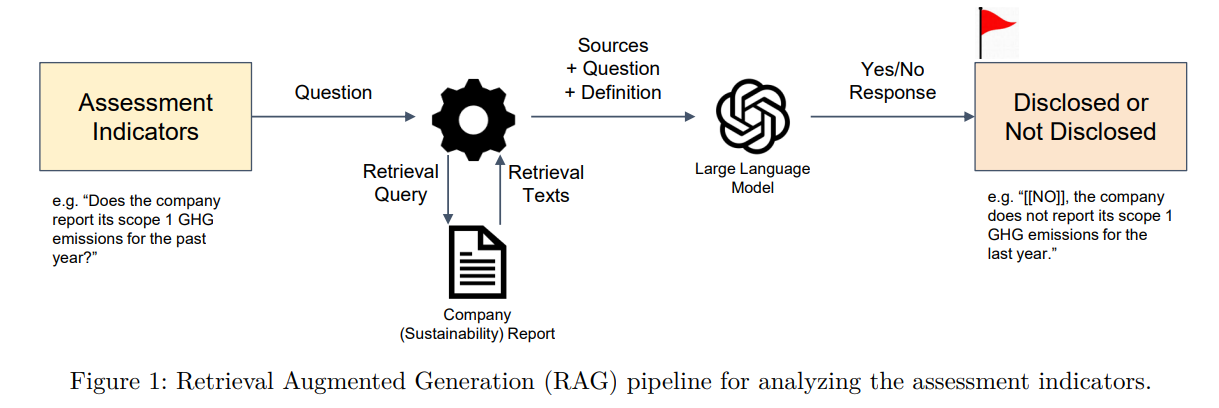

Use a question, find relevant content to the question in sustainability reports and then augment the prompt and answer the question. We just use their functions in the code to create the pipeline (see [their GitHub](https://github.com/tobischimanski/transition_NLP/tree/main)). This, in turn, uses LlamaIndex, an open-source framework, for the creation of the report-level dataset.

Consider the following code to setup a RAG system as given (and download a report).

In [ ]:
import requests
import os
import html
from IPython.display import display, HTML
import json

from llama_index.core import SimpleDirectoryReader, VectorStoreIndex
from llama_index.core.node_parser import SentenceSplitter
from llama_index.core.retrievers import VectorIndexRetriever
from llama_index.embeddings.openai import OpenAIEmbedding
from llama_index.readers.file import PyMuPDFReader


# function that helps downloading reports
def downloadReport(url, local_file_path):
  # Make the request to fetch the content of the file
  response = requests.get(url)

  # Check if the request was successful
  if response.status_code == 200:
      # Open the local file in write-binary mode and save the content
      with open(local_file_path, 'wb') as file:
          file.write(response.content)
      print(f'Report downloaded and saved as {local_file_path}')
  else:
      print(f'Failed to download the report. Status code: {response.status_code}')


def createRetriever(REPORT, CHUNK_SIZE, CHUNK_OVERLAP, TOP_K, API_KEY):
    os.environ["OPENAI_API_KEY"] = API_KEY
    documents = SimpleDirectoryReader(
        input_files=[REPORT],
        file_extractor={".pdf": PyMuPDFReader()}
    ).load_data()

    # Force page_label metadata to exist
    for page_idx, doc in enumerate(documents, start=1):
        doc.metadata["page_label"] = str(page_idx)
        doc.metadata["page_number"] = page_idx
        doc.metadata["file_name"] = os.path.basename(str(REPORT))

    parser = SentenceSplitter(
        chunk_size=CHUNK_SIZE,
        chunk_overlap=CHUNK_OVERLAP
    )

    nodes = parser.get_nodes_from_documents(documents)

    # Make sure chunks also have page metadata
    for node in nodes:
        if "page_label" not in node.metadata:
            node.metadata["page_label"] = node.metadata.get("page_number", "unknown")
    index = VectorStoreIndex(
        nodes,
        embed_model=OpenAIEmbedding(
            model="text-embedding-3-small",
            embed_batch_size=50
        ),
        show_progress=True
    )

    retriever = VectorIndexRetriever(
        index=index,
        similarity_top_k=TOP_K
    )

    return retriever

def createSources(retriever, QUERY_STR, REPORT):
    sources = []
    report_name = os.path.basename(str(REPORT))
    html_parts = []
    html_parts.append(f"<h2>SOURCES for {html.escape(report_name)}</h2>")
    html_parts.append(f"<h3>Searched for: {html.escape(QUERY_STR)}</h3>")
    retrieved_nodes = retriever.retrieve(QUERY_STR)

    for node in retrieved_nodes:
        page_num = node.metadata.get("page_label", "unknown")
        source = node.get_content().replace("\n", " ")
        source = " ".join(source.split())

        source_string = f"PAGE {page_num}: {source}"
        sources.append(source_string)

        html_parts.append(
            f"<h3>PAGE {html.escape(str(page_num))}:</h3>"
            f"<p>{html.escape(source)}</p>"
        )

    sources_block = " ".join(html_parts)
    display(HTML(sources_block))

    return "\n\n".join(sources)

def visualize_answer(answer):

    if isinstance(answer, str):
        answer = json.loads(answer.replace("```json", "").replace("```", "").strip())

    answer_html = f"""
    <h3>Answer:</h3>
    <p>{answer['ANSWER']}</p>

    <h3>Source Pages:</h3>
    <p>{', '.join(map(str, answer['SOURCE_PAGES']))}</p>
    """

    display(HTML(answer_html))

We use Saudi Aramco's report that can be found [here](https://www.aramco.com/-/media/downloads/sustainability-report/report-2022/2022-sustainability-report-en.pdf).

In [ ]:
# dowload a random report for analysis
url = "https://www.aramco.com/-/media/downloads/sustainability-report/report-2022/2022-sustainability-report-en.pdf"
REPORT = "2023_sustainability_report.pdf"
downloadReport(url, REPORT)

Since we are used OpenAI models for the search and generation, we again need our OpenAI key. Follow [this tutorial](https://www.merge.dev/blog/chatgpt-api-key) to create the key.

In [ ]:
# these commands just make the openai key globally available for both OpenAI and LLamaIndex
API_KEY = "sk-..."

Your ⭐first task⭐ is to make sense of the code. You just use the code to retrieve sources from a report. For this, you first need to create a retriever and then use the retriever and a question to retrieve sources.

In [ ]:
### TASK 1.1
# Create Retriever

# We use a report that is available in the GitHub of the project: CSR_VOW3_2022.pdf
REPORT = "2023_sustainability_report.pdf"
# CHUNK_SIZE (int): desired word count of the paragraphs
### YOUR CODE HERE ###

# CHUNK_OVERLAP (int): overlap of the paragraphs
### YOUR CODE HERE ###

# TOP_K (in): number of retrieved paragraphs for a search
### YOUR CODE HERE ###

# Create retriever (this may take 30 seconds)
### YOUR CODE HERE ###

In [ ]:
### TASK 1.2
# Obtain Sources

# Question inspired by: https://papers.ssrn.com/sol3/papers.cfm?abstract_id=4826207
question = "Does the company report its GHG emission reduction interim targets for achieving the overall goal?"

sources = ### YOUR CODE HERE ###

Your ⭐second task⭐ is to help to create a prompt template that uses the sources to answer the question.

Hint: you can also look into [the paper](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=4826207) for a very detailled prompt.

In [ ]:
### TASK 2

### YOUR CODE HERE ###
prompt_template = f"""
{sources}


{question}
"""

print(prompt_template)

Your ⭐third task⭐ is to use the prompt to answer the question. Hint: See the functions used in Exercise 2.

In [ ]:
### TASK 3

### YOUR CODE HERE ###

Ok, now you've understood the basics of RAG and how to do it. We have looked at emission targets. Now, your ⭐fourth task⭐ is writing a prompt to obtain emissions of the firm. This can be very helpful if you are interested in emission tracking of firms. Hence, you have to write a question looking for Scope 1 emissions of the firm, you have to write a prompt template, create the prompt, obtain the sources and finally answer the question. In a nutshell, all of the above in one task.

**Important**: Since you are asking for concrete numbers, the answer can be very easily evaluated. Check whether the answer is correct. This is important in understanding the performance capabilities of LLMs.

In [ ]:
### TASK 4

### YOUR CODE HERE ###

Now, also consider the [sustainability report of Apple for 2024](https://www.apple.com/environment/pdf/Apple_Environmental_Progress_Report_2024.pdf). Your ⭐fifth task⭐ is to find out the scope 1 emissions for Apple.

**Important**: Again, do you retrieve the right number? What are challenges and how could you further automate an analysis?

In [ ]:
### TASK 5
url = "https://www.apple.com/environment/pdf/Apple_Environmental_Progress_Report_2024.pdf"
REPORT = "2024_apple_sustainability_report.pdf"
downloadReport(url, REPORT)

### YOUR CODE HERE ###
# Note I would increase the CHUNK_SIZE from 200 to 400. Can you guess why?


**Nice to know**: This is the naive way of implementing RAG. Better retrieval algorithms and generation models will improve the performance of the RAG system drastically (see for instance [this publication at ACL](https://arxiv.org/abs/2402.08277#:~:text=Advances%20towards%20more%20faithful%20and,the%20answers%20on%20reliable%20sources.) - the most important AI conference for Natural Language Processing). There is also projects that use [RAG to incorporate the guidelines of the Taskforce on Climate-related Financial Disclosures](https://aclanthology.org/2023.emnlp-demo.3/) and [RAG for assessing companies' nature disclosures](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=4860331).

## Solution

In [ ]:
### TASK 1.1
# Create Retriever
REPORT = "2023_sustainability_report.pdf"
# CHUNK_SIZE (int): desired word count of the paragraphs
CHUNK_SIZE = 200
# CHUNK_OVERLAP (int): overlap of the paragraphs
CHUNK_OVERLAP = 50
# TOP_K (in): number of retrieved paragraphs for a search
TOP_K = 5

# Create retriever (this may take 30 seconds)
retriever = createRetriever(REPORT, CHUNK_SIZE, CHUNK_OVERLAP, TOP_K, API_KEY)

In [ ]:
### TASK 1.2
# Obtain Sources

# Question inspired by: https://papers.ssrn.com/sol3/papers.cfm?abstract_id=4826207
question = "Does the company report its GHG emission reduction interim targets for achieving the overall goal?"

sources = createSources(retriever, question, REPORT)

In [ ]:
### TASK 2

prompt_template = f"""You are a senior sustainability analyst with expertise in climate science evaluating a company ’s climate - related transition plan and strategy.

You are presented with the following sources from the company ’s report :
--------------------- [BEGIN OF SOURCES]\n
{sources}\n
--------------------- [END OF SOURCES]\n
Given the source information and no prior knowledge , your main task is to respond to the posed question encapsulated in "||".
Question : ||{question}||

Start your answer with a "[[YES]]" or "[[NO]]" depending on whether you would answer the question with a yes or no.
Always compliment your judgment on yes or no with a short explanation that summarizes the sources in an informative way , i.e. provide details.

Format your answer in JSON format with the two keys : ANSWER (this should contain your answer string without sources), and SOURCE_PAGES (this should be a list of the SOURCE numbers that were referenced in your answer).
Your FINAL_ANSWER in JSON (ensure there’s no format error):
"""

print(prompt_template)

In [ ]:
### TASK 3
answer = get_model_response(CLIENT, MODEL_NAME, prompt_template)
visualize_answer(answer)

In [ ]:
### TASK 4

# question and sources
question = "What are the scope 1 emissions of the firm?"

sources = createSources(retriever, question, REPORT)

# prompt template
prompt_template = f"""You are a senior sustainability analyst with expertise in climate science evaluating a company ’s climate - related transition plan and strategy.

You are presented with the following sources from the company ’s report :
--------------------- [BEGIN OF SOURCES]\n
{sources}\n
--------------------- [END OF SOURCES]\n
Given the source information and no prior knowledge , your main task is to respond to the posed question encapsulated in "||".
Question : ||{question}||

Answer the question with a single number and unit. Output nothing else.

Format your answer in JSON format with the two keys : ANSWER (this should contain your answer), and SOURCE_PAGES (this should be a list of the SOURCE numbers that were referenced in your answer).
Your FINAL_ANSWER in JSON (ensure there’s no format error):
"""

# print(prompt_template)

# answer
answer = get_model_response(CLIENT, MODEL_NAME, prompt_template)
visualize_answer(answer)

In [ ]:
### TASK 5

# Create Retriever
REPORT = "2024_apple_sustainability_report.pdf"
# CHUNK_SIZE (int): desired word count of the paragraphs
# Note I would increase the CHUNK_SIZE from 200 to 400. Can you guess why?
# --> The reason is that the answer is in a table. The chunking might break the table structure
# --> in a way that doesn't preserve the context entirely.
CHUNK_SIZE = 400
# CHUNK_OVERLAP (int): overlap of the paragraphs
CHUNK_OVERLAP = 50
# TOP_K (in): number of retrieved paragraphs for a search
TOP_K = 5

# Create retriever (this may take 30 seconds)
retriever = createRetriever(REPORT, CHUNK_SIZE, CHUNK_OVERLAP, TOP_K, API_KEY)

# question and sources
question = "What are the scope 1 emissions of the firm?"
sources = createSources(retriever, question, REPORT)

# prompt template
prompt_template = f"""You are a senior sustainability analyst with expertise in climate science evaluating a company ’s climate - related transition plan and strategy.

You are presented with the following sources from the company ’s report :
--------------------- [BEGIN OF SOURCES]\n
{sources}\n
--------------------- [END OF SOURCES]\n
Given the source information and no prior knowledge , your main task is to respond to the posed question encapsulated in "||".
Question : ||{question}||

Answer the question with a single number and unit. Output nothing else.

Format your answer in JSON format with the two keys : ANSWER (this should contain your answer), and SOURCE_PAGES (this should be a list of the SOURCE numbers that were referenced in your answer).
Your FINAL_ANSWER in JSON (ensure there’s no format error):
"""

# print(prompt_template)

# answer
answer = get_model_response(CLIENT, MODEL_NAME, prompt_template)
visualize_answer(answer)

# Limitations

In here, we introduce simple usage patterns of LLMs for classification and document-level question answering. In the last tasks, we have already started thinking about "What could go wrong?". LLMs can hallucinate, i.e., producing contents that are just not there or factually incorrect. One reason may be interpreting the contents wrongly or having malicious input.

The latter is also a major limitation. While models can get better, stronger, faster, the input quality will likely be the single most important factor for output quality. Imagine you ask best chess player in the world to win a game against a friend of yours but you don't tell him the positions of the pieces on the board.

On the other hand, with increasing model capabilities, the hallucinations get more sophisticated and hard to detect. What can you do? Task design and evaluation are central. In the emissions task, it was easy to evaluate model failure because there is only one answer. This is good. In more qualitative tasks, it is worthwhile to evaluate the answers with experts.

In conclusion, LLMs are powerful tools but blind trust may cause more harm than help. Good input data, clear tasks, and evaluations are central.